# Renal Framework End-to-End Demo

This notebook runs the modular framework end-to-end:

1. Config + data
2. TabPFN preprocessing + model fit
3. Walk-forward yearly evaluation
4. Embedding extraction + split protocol
5. Concept decomposition (DL + SAE)
6. Rule extraction (decision trees)
7. CAV/TCAV robust testing
8. Phenotype characterization
9. ACE necessity/sufficiency + drift
10. Reporting and visualization utilities

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch

from src.config import load_config
from src.io_utils import ensure_dir, load_feather
from src.logging_utils import get_logger

from src.tabpfn_pipeline.preprocessing import (
    TabPFNPrepConfig,
    canonicalize_event_df,
    prepare_tabpfn_rows,
)

from src.tabpfn_pipeline.evaluation import (
    TabPFNEvalConfig,
    fit_drift_resilient_tabpfn,
    walkforward_evaluate_tabpfn,
    save_tabpfn_temporal_artifacts,
)

In [2]:
cfg = load_config("configs/base.yaml")
logger = get_logger("demo.tabpfn.step1")

RESULTS_DIR = ensure_dir(Path(cfg.paths.results_dir) / "demo_tabpfn")
RUN_ID = "demo_tabpfn_step1"
OUT_DIR = ensure_dir(RESULTS_DIR / RUN_ID)

print("RESULTS_DIR:", RESULTS_DIR)
print("OUT_DIR:", OUT_DIR)
print("DATA:", cfg.paths.data_feather)

RESULTS_DIR: results/demo_tabpfn
OUT_DIR: results/demo_tabpfn/demo_tabpfn_step1
DATA: ../renal/tidy_event_data.feather


In [3]:
df_raw = load_feather(cfg.paths.data_feather)
df = canonicalize_event_df(df_raw)

print(f"Rows: {len(df):,}")
print(f"Patients: {df['patient_id'].nunique():,}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
print(f"Distinct events: {df['event'].nunique():,}")
df.head()

Rows: 9,559,286
Patients: 67,267
Years: 1997 - 2015
Distinct events: 6,207


,date,patient_id,event,year
0,2001-07-01,26250,EVENT_C1DIALISE_HD,2001
1,2001-07-01,26250,DIAGN_N180,2001
2,2001-08-01,26250,EVENT_C1DIALISE_HD,2001
3,2001-08-01,26250,DIAGN_N180,2001
4,2001-09-01,26250,EVENT_C1DIALISE_HD,2001


In [4]:
prep_cfg = TabPFNPrepConfig(
    rng_seed=cfg.tabpfn.rng_seed,
    target_pos_lines=5000,
    target_neg_lines=5000,
    max_total_rows=10000,
    final_top_k=cfg.ts.final_top_k,
    m_candidates=cfg.ts.m_candidates,
    forced_train_year_start=cfg.ts.train_year_start or 1997,
    forced_train_year_end=cfg.ts.train_year_end or 2006,
)

lgb_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "seed": cfg.tabpfn.rng_seed,
    "n_jobs": 4,
    "num_leaves": 64,
    "learning_rate": 0.1,
    "max_depth": -1,
}

In [5]:
prep_out = prepare_tabpfn_rows(df=df, cfg=prep_cfg, lgb_params=lgb_params)

train_rows = prep_out["train_rows"]
test_rows = prep_out["test_rows"]
top_k_events = prep_out["top_k_events"]
train_years = prep_out["train_years"]
test_years = prep_out["test_years"]

print("train_rows:", train_rows.shape)
print("test_rows :", test_rows.shape)
print("n top_k_events:", len(top_k_events))
print("train_years:", train_years)
print("test_years :", test_years)

train_rows: (9211, 503)
test_rows : (21900, 503)
n top_k_events: 500
train_years: [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006]
test_years : [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]


In [6]:
X_train_np = train_rows[top_k_events].to_numpy(dtype=np.float32, copy=True)
y_train_np = (train_rows["DEATH"] > 0).astype(int).to_numpy(copy=True)
years_train_np = train_rows["year"].astype(int).to_numpy(copy=True)

print("X_train_np:", X_train_np.shape)
print("y_train_np:", y_train_np.shape, "| pos_ratio:", y_train_np.mean())

X_train_np: (9211, 500)
y_train_np: (9211,) | pos_ratio: 0.17424818152209315


In [7]:
eval_cfg = TabPFNEvalConfig(
    rng_seed=cfg.tabpfn.rng_seed,
    tabpfn_model_name=cfg.tabpfn.model_name,
    batch_size_predict=cfg.tabpfn.default_batch_predict,
    run_id=RUN_ID,
)

fit_out = fit_drift_resilient_tabpfn(
    X_train_np=X_train_np,
    y_train_np=y_train_np,
    train_years=years_train_np,
    eval_cfg=eval_cfg,
)

drift_model = fit_out["model"]
model_add_x_device = fit_out["model_add_x_device"]
example_add_shape = fit_out["example_add_shape"]

print(f"Fit time: {fit_out['fit_time_sec']:.2f}s")
print("additional_x device:", model_add_x_device)
print("example_add_shape:", example_add_shape)

Initialized decoder for standard with (None, 10)  and nout 10
Fit time: 1.59s
additional_x device: cpu
example_add_shape: (9211, 1, 1)


In [8]:
wf = walkforward_evaluate_tabpfn(
    drift_model=drift_model,
    test_rows=test_rows,
    top_k_events=top_k_events,
    train_years=train_years,
    model_add_x_device=model_add_x_device,
    batch_size_predict=cfg.tabpfn.default_batch_predict,
    example_add_shape=example_add_shape,
)

results_per_year = wf["results_per_year"]
year_to_domain_combined = wf["year_to_domain_combined"]
test_rows_checked = wf["test_rows_checked"]

results_df = pd.DataFrame(results_per_year).sort_values("year").reset_index(drop=True)
results_df

/home/anahealth/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.2 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


,year,n_samples,n_deaths,f1_macro,f1_pos,infer_time_sec
0,2007,1894,143,0.634787,0.338028,75.547516
1,2008,2393,179,0.649099,0.369610,55.596090
2,2009,2485,219,0.664688,0.400756,55.890607
3,2010,2594,216,0.627816,0.334545,67.028161
4,2011,2520,258,0.617922,0.320144,56.013098
5,2012,2529,215,0.598367,0.277886,56.025484
6,2013,2577,191,0.606524,0.290766,66.858364
7,2014,2605,225,0.620258,0.322004,66.983194
8,2015,2303,97,0.615471,0.279863,55.888826


In [9]:
save_tabpfn_temporal_artifacts(
    out_dir=OUT_DIR,
    results_per_year=results_per_year,
    train_rows=train_rows,
    test_rows=test_rows_checked,
    meta={
        "run_id": RUN_ID,
        "fit_time_sec": fit_out["fit_time_sec"],
        "total_infer_time_sec": wf["total_infer_time_sec"],
        "n_features": len(top_k_events),
    },
)

print("Saved Step 1 artifacts to:", OUT_DIR)

Saved Step 1 artifacts to: results/demo_tabpfn/demo_tabpfn_step1


In [10]:
from src.tabpfn_pipeline.embedding import (
    EmbeddingExtractConfig,
    fit_or_load_feature_scaler,
    load_or_extract_embeddings,
    fit_embedding_scaler,
    transform_embeddings,
    temporal_test_subsplits,
)

In [11]:
feature_cols = list(top_k_events)

X_train_df = train_rows[feature_cols].copy()
X_test_df = test_rows_checked[feature_cols].copy()

print("X_train_df:", X_train_df.shape)
print("X_test_df :", X_test_df.shape)

X_train_df: (9211, 500)
X_test_df : (21900, 500)


In [12]:
scaler_feature_path = RESULTS_DIR / "scaler_standard.pkl"

scaler_feature, X_train_df_norm, X_test_df_norm = fit_or_load_feature_scaler(
    train_rows=train_rows,
    test_rows=test_rows_checked,
    feature_cols=feature_cols,
    scaler_path=scaler_feature_path,
)

print("Feature scaler path:", scaler_feature_path)
print("X_train_df_norm:", X_train_df_norm.shape)
print("X_test_df_norm :", X_test_df_norm.shape)

Feature scaler path: results/demo_tabpfn/scaler_standard.pkl
X_train_df_norm: (9211, 500)
X_test_df_norm : (21900, 500)


In [13]:
X_test_np = X_test_df.to_numpy(dtype=np.float32, copy=True)
years_train_np = train_rows["year"].astype(int).to_numpy(copy=True)
years_test_np = test_rows_checked["year"].astype(int).to_numpy(copy=True)

combined_years = sorted(set(years_train_np.tolist()).union(set(years_test_np.tolist())))
year_to_domain_combined = {y: i for i, y in enumerate(combined_years)}

print("Combined years:", combined_years[:3], "...", combined_years[-3:])
print("Num domains:", len(year_to_domain_combined))

Combined years: [1998, 1999, 2000] ... [2013, 2014, 2015]
Num domains: 18


In [14]:
EMBEDDINGS_DIR = ensure_dir(RESULTS_DIR / "embeddings")

emb_cfg = EmbeddingExtractConfig(
    batch_size=cfg.tabpfn.default_batch_predict,
    max_extract=None,
    use_cache=True,
)

emb_out = load_or_extract_embeddings(
    model=drift_model,
    X_train_np=X_train_np,
    X_test_np=X_test_np,
    years_train=years_train_np,
    years_test=years_test_np,
    year_to_domain_map=year_to_domain_combined,
    embeddings_dir=EMBEDDINGS_DIR,
    cfg=emb_cfg,
    device=model_add_x_device,
    example_add_shape=example_add_shape,
)

train_emb = emb_out["train_emb"]
test_emb = emb_out["test_emb"]
train_emb_flat = emb_out["train_emb_flat"]
test_emb_flat = emb_out["test_emb_flat"]

print("train_emb:", train_emb.shape)
print("test_emb :", test_emb.shape)
print("train_emb_flat:", train_emb_flat.shape)
print("test_emb_flat :", test_emb_flat.shape)

train_emb: (9211, 1, 192)
test_emb : (21900, 1, 192)
train_emb_flat: (9211, 192)
test_emb_flat : (21900, 192)


In [15]:
scaler_emb = fit_embedding_scaler(train_emb_flat)
train_emb_flat_norm = transform_embeddings(scaler_emb, train_emb_flat)
test_emb_flat_norm = transform_embeddings(scaler_emb, test_emb_flat)

print("train_emb_flat_norm:", train_emb_flat_norm.shape)
print("test_emb_flat_norm :", test_emb_flat_norm.shape)

train_emb_flat_norm: (9211, 192)
test_emb_flat_norm : (21900, 192)


In [16]:
y_test = (test_rows_checked["DEATH"] > 0).astype(int).to_numpy(copy=True)

split_idx = temporal_test_subsplits(
    y_test=y_test,
    random_state=cfg.tabpfn.rng_seed,
)

idx_test_discover = split_idx["idx_test_discover"]
idx_test_cav_train = split_idx["idx_test_cav_train"]
idx_test_tcav_eval = split_idx["idx_test_tcav_eval"]
idx_test_held_out = split_idx["idx_test_held_out"]

print("Discovery :", len(idx_test_discover), f"({len(idx_test_discover)/len(y_test):.1%})")
print("CAV Train :", len(idx_test_cav_train), f"({len(idx_test_cav_train)/len(y_test):.1%})")
print("TCAV Eval :", len(idx_test_tcav_eval), f"({len(idx_test_tcav_eval)/len(y_test):.1%})")
print("Held-out  :", len(idx_test_held_out), f"({len(idx_test_held_out)/len(y_test):.1%})")

Discovery : 7227 (33.0%)
CAV Train : 7336 (33.5%)
TCAV Eval : 3668 (16.7%)
Held-out  : 3669 (16.8%)


In [17]:
y_test_discover = y_test[idx_test_discover]
y_test_cav_train = y_test[idx_test_cav_train]
y_test_tcav_eval = y_test[idx_test_tcav_eval]
y_test_held_out = y_test[idx_test_held_out]

years_test_discover = years_test_np[idx_test_discover]
years_test_cav_train = years_test_np[idx_test_cav_train]
years_test_tcav_eval = years_test_np[idx_test_tcav_eval]
years_test_held_out = years_test_np[idx_test_held_out]

print("Discovery years:", years_test_discover.min(), "-", years_test_discover.max())
print("CAV years      :", years_test_cav_train.min(), "-", years_test_cav_train.max())
print("TCAV years     :", years_test_tcav_eval.min(), "-", years_test_tcav_eval.max())
print("Held-out years :", years_test_held_out.min(), "-", years_test_held_out.max())

Discovery years: 2007 - 2015
CAV years      : 2007 - 2015
TCAV years     : 2007 - 2015
Held-out years : 2007 - 2015


In [19]:
from src.io_utils import save_json
save_json(
    {
        "n_test": int(len(y_test)),
        "split_sizes": {
            "discover": int(len(idx_test_discover)),
            "cav_train": int(len(idx_test_cav_train)),
            "tcav_eval": int(len(idx_test_tcav_eval)),
            "held_out": int(len(idx_test_held_out)),
        },
        "embedding_shapes": {
            "train_emb": list(train_emb.shape),
            "test_emb": list(test_emb.shape),
            "train_emb_flat": list(train_emb_flat.shape),
            "test_emb_flat": list(test_emb_flat.shape),
        },
    },
    OUT_DIR / "step2_metadata.json",
)

print("Saved Step 2 metadata:", OUT_DIR / "step2_metadata.json")

Saved Step 2 metadata: results/demo_tabpfn/demo_tabpfn_step1/step2_metadata.json


In [20]:
from src.tabpfn_pipeline.concept_learning import (
    DictionaryLearningConfig,
    SAEConfig,
    fit_dictionary_learning,
    fit_sae,
    get_concept_activations,
)
from src.tabpfn_pipeline.reporting import decomposition_quality_report

In [21]:
embeddings_discovery = test_emb_flat_norm[idx_test_discover]
embeddings_cav_train = test_emb_flat_norm[idx_test_cav_train]

print("embeddings_discovery:", embeddings_discovery.shape)
print("embeddings_cav_train:", embeddings_cav_train.shape)

embeddings_discovery: (7227, 192)
embeddings_cav_train: (7336, 192)


In [22]:
dl_cfg = DictionaryLearningConfig(
    n_components=cfg.tabpfn.n_factors,   # e.g., N_FACTORS from config
    transform_algorithm="lasso_lars",
    max_iter=1000,
    random_state=cfg.tabpfn.rng_seed,
)

dl_info = fit_dictionary_learning(
    embeddings_discovery=embeddings_discovery,
    embeddings_cav_train=embeddings_cav_train,
    cfg=dl_cfg,
)

print("DL W_latent shape:", dl_info["W_latent"].shape)
print("DL discovery activations:", dl_info["activations_discovery_train"].shape)
print("DL cav activations:", dl_info["activations_cav_train"].shape)

DL W_latent shape: (192, 8)
DL discovery activations: (7227, 8)
DL cav activations: (7336, 8)


In [23]:
sae_cfg = SAEConfig(
    emb_dim=train_emb_flat_norm.shape[1],  # usually 192
    n_factors=int(192 * 1.5),              # notebook-parity expansion
    alpha_sparse=1e-1,
    lr=1e-3,
    epochs=1000,                           # reduce for quick demo if needed
    use_decoder_bias=False,
    device="cpu",
)

sae_info = fit_sae(
    embeddings_discovery=embeddings_discovery,
    cfg=sae_cfg,
    verbose_every=50,
)

print("SAE codes (discovery):", sae_info["codes_train_sae"].shape)
print("SAE decoder atoms:", sae_info["decoder_atoms_sae"].shape)

[SAE] epoch=0050 loss=0.134561 sparsity=44.39%
[SAE] epoch=0100 loss=0.105520 sparsity=47.91%
[SAE] epoch=0150 loss=0.092147 sparsity=53.98%
[SAE] epoch=0200 loss=0.082950 sparsity=60.30%
[SAE] epoch=0250 loss=0.076040 sparsity=65.02%
[SAE] epoch=0300 loss=0.069823 sparsity=68.87%
[SAE] epoch=0350 loss=0.064149 sparsity=72.46%
[SAE] epoch=0400 loss=0.058665 sparsity=75.40%
[SAE] epoch=0450 loss=0.053447 sparsity=78.47%
[SAE] epoch=0500 loss=0.048911 sparsity=80.99%
[SAE] epoch=0550 loss=0.045187 sparsity=83.36%
[SAE] epoch=0600 loss=0.042310 sparsity=85.08%
[SAE] epoch=0650 loss=0.040087 sparsity=86.47%
[SAE] epoch=0700 loss=0.038487 sparsity=87.47%
[SAE] epoch=0750 loss=0.036978 sparsity=88.21%
[SAE] epoch=0800 loss=0.035441 sparsity=88.85%
[SAE] epoch=0850 loss=0.033926 sparsity=89.40%
[SAE] epoch=0900 loss=0.032238 sparsity=89.82%
[SAE] epoch=0950 loss=0.030423 sparsity=90.20%
[SAE] epoch=1000 loss=0.028648 sparsity=90.55%
SAE codes (discovery): (7227, 288)
SAE decoder atoms: (192, 

In [24]:
codes_train_sae = sae_info["codes_train_sae"]

sparsity_level = (codes_train_sae <= 1e-5).mean()
active_per_sample = (codes_train_sae > 1e-5).sum(axis=1).mean()

print(f"SAE near-zero activations: {sparsity_level:.2%}")
print(f"SAE active neurons/sample: {active_per_sample:.2f} / {codes_train_sae.shape[1]}")
print(f"SAE mean abs activation: {np.abs(codes_train_sae).mean():.4f}")
print(f"SAE max activation: {codes_train_sae.max():.4f}")

SAE near-zero activations: 90.56%
SAE active neurons/sample: 27.20 / 288
SAE mean abs activation: 0.2452
SAE max activation: 24.3134


In [25]:
# Example on TCAV eval split embeddings
emb_tcav_eval = test_emb_flat_norm[idx_test_tcav_eval]

acts_dl = get_concept_activations(
    embeddings=emb_tcav_eval,
    source="dl",
    dict_learning_info=dl_info,
)

acts_sae = get_concept_activations(
    embeddings=emb_tcav_eval,
    source="sae",
    model_sae=sae_info["model_sae"],
    device="cpu",
)

print("TCAV activations (DL):", acts_dl.shape)
print("TCAV activations (SAE):", acts_sae.shape)

TCAV activations (DL): (3668, 8)
TCAV activations (SAE): (3668, 288)


In [26]:
quality_report = decomposition_quality_report(
    codes_sae=sae_info["codes_train_sae"],
    decoder_atoms_sae=sae_info["decoder_atoms_sae"],
    dict_codes=dl_info["activations_discovery_train"],
    dict_atoms=dl_info["W_latent"],
    threshold=0.5,
)

quality_report

{'sae_atom_max_offdiag_cos': 0.29046450859852374,
 'sae_atom_mean_offdiag_cos': 0.055132643231981124,
 'sae_atom_pairs_gt_thr': 0,
 'sae_code_max_offdiag_cos': 0.9972581420497195,
 'sae_code_mean_offdiag_cos': 0.030800981974258766,
 'sae_code_pairs_gt_thr': 399,
 'dl_atom_max_offdiag_cos': 0.9417717307821944,
 'dl_atom_mean_offdiag_cos': 0.6763931057186998,
 'dl_atom_pairs_gt_thr': 28,
 'dl_code_max_offdiag_cos': 0.47799922566214126,
 'dl_code_mean_offdiag_cos': 0.18058699674383905,
 'dl_code_pairs_gt_thr': 0,
 'sae_sparsity': 0.9055581499930815,
 'dl_sparsity': 0.4790542410405424}

In [27]:
save_json(
    {
        "dl_shapes": {
            "W_latent": list(dl_info["W_latent"].shape),
            "activations_discovery_train": list(dl_info["activations_discovery_train"].shape),
            "activations_cav_train": list(dl_info["activations_cav_train"].shape),
        },
        "sae_shapes": {
            "codes_train_sae": list(sae_info["codes_train_sae"].shape),
            "decoder_atoms_sae": list(sae_info["decoder_atoms_sae"].shape),
        },
        "quality_report": quality_report,
    },
    OUT_DIR / "step3_decomposition_metadata.json",
)

print("Saved:", OUT_DIR / "step3_decomposition_metadata.json")

Saved: results/demo_tabpfn/demo_tabpfn_step1/step3_decomposition_metadata.json


In [28]:
from src.tabpfn_pipeline.rules import (
    RuleExtractionConfig,
    extract_rules_per_percentile,
    select_best_percentile,
    rules_to_dataframe,
)

In [29]:
rng = np.random.default_rng(42)

n_cav = len(idx_test_cav_train)
idx_local = np.arange(n_cav)

idx_dt_train = rng.choice(idx_local, size=int(n_cav * 0.5), replace=False)
idx_cav_final_train = np.setdiff1d(idx_local, idx_dt_train)

print("Total CAV split:", n_cav)
print("DT train:", len(idx_dt_train))
print("CAV final train:", len(idx_cav_final_train))

Total CAV split: 7336
DT train: 3668
CAV final train: 3668


In [30]:
# Raw features from test CAV split
X_cav_train_df = test_rows_checked.iloc[idx_test_cav_train][feature_cols].reset_index(drop=True)
X_feat_dt_train = X_cav_train_df.iloc[idx_dt_train].to_numpy()

# Concept activations on full CAV split (choose source: "sae" or "dl")
ANALYSIS_SOURCE = "sae"

if ANALYSIS_SOURCE == "sae":
    codes_cav_all = get_concept_activations(
        embeddings=test_emb_flat_norm[idx_test_cav_train],
        source="sae",
        model_sae=sae_info["model_sae"],
        device="cpu",
    )
else:
    codes_cav_all = get_concept_activations(
        embeddings=test_emb_flat_norm[idx_test_cav_train],
        source="dl",
        dict_learning_info=dl_info,
    )

codes_dt_train = codes_cav_all[idx_dt_train]
codes_cav_final_train = codes_cav_all[idx_cav_final_train]

print("X_feat_dt_train:", X_feat_dt_train.shape)
print("codes_dt_train:", codes_dt_train.shape)
print("codes_cav_final_train:", codes_cav_final_train.shape)

X_feat_dt_train: (3668, 500)
codes_dt_train: (3668, 288)
codes_cav_final_train: (3668, 288)


In [31]:
rules_cfg = RuleExtractionConfig(
    percentiles=[90, 80, 70, 60, 50],
    max_depth=15,
    min_samples_leaf=0.01,
    min_positive_samples=50,
    min_rule_precision=0.90,
    min_rule_recall=0.25,
    random_state=42,
)

In [32]:
rules_per_percentile, thresholds_per_p = extract_rules_per_percentile(
    X_feat_dt_train=X_feat_dt_train,
    factor_scores_dt_train=codes_dt_train,
    feature_cols=feature_cols,
    cfg=rules_cfg,
)

for p in rules_cfg.percentiles:
    print(f"Percentile {p}: {len(rules_per_percentile[p])} rules")

Percentile 90: 13 rules
Percentile 80: 14 rules
Percentile 70: 17 rules
Percentile 60: 17 rules
Percentile 50: 16 rules


In [33]:
best_p = select_best_percentile(rules_per_percentile)
rules_df_best = rules_to_dataframe(rules_per_percentile, best_p)

print("Best percentile:", best_p)
print("Number of rules at best percentile:", len(rules_df_best))
rules_df_best.head(20)

Best percentile: 70
Number of rules at best percentile: 17


,Factor,Path,Class,Top_features,Precision,Recall,tree_text
0,46,EVENT_C1DIALISE_HD > 8.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.997614635744834), (EVE...",1.000000,0.397436,|--- EVENT_C1DIALISE_HD <= 8.50\n| |--- EVEN...
1,80,EVENT_C1DIALISE_HD > 11.50 AND EVENT_c2MED_ER...,1,"[(EVENT_c2MED_ERITRO, 0.5021705701404917), (EV...",0.920000,0.345000,|--- EVENT_C1DIALISE_HD <= 11.50\n| |--- DIA...
2,86,EVENT_C1DIALISE_HD > 12.50 AND EVENT_C1DIALIS...,1,"[(EVENT_C1DIALISE_HD, 0.9126358043088972), (DI...",1.000000,0.407950,|--- EVENT_C1DIALISE_HD <= 12.50\n| |--- EVE...
3,93,EVENT_C1DIALISE_HD > 15.50,1,"[(EVENT_C1DIALISE_HD, 0.9979965755996622), (EV...",0.942308,0.671233,|--- EVENT_C1DIALISE_HD <= 15.50\n| |--- EVE...
4,106,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.9043297807836003), (EV...",1.000000,0.436464,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- EVEN...
5,138,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.8345601319712288), (EV...",1.000000,0.304985,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- EVEN...
6,153,DIAGN_N188 <= 1.50 AND EVENT_C1DIALISE_HD <= 1...,1,"[(EVENT_C1DIALISE_HD, 0.7284353483425817), (DI...",0.924242,0.458647,|--- DIAGN_N188 <= 1.50\n| |--- EVENT_C1DIAL...
7,156,EVENT_C1DIALISE_HD > 9.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.9941658696447638), (EV...",1.000000,0.631236,|--- EVENT_C1DIALISE_HD <= 9.50\n| |--- EVEN...
8,175,EVENT_c3ACESSO_CT > 1.50 AND EVENT_C6INTERNA_...,1,"[(EVENT_C6INTERNA_INTER, 0.45215905201848744),...",0.911111,0.320312,|--- EVENT_c3ACESSO_CT <= 1.50\n| |--- EVENT...
9,184,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.9990303741179982), (DI...",1.000000,0.625926,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- clas...


In [34]:
# These are used in TCAV/CAV training step
emb_cav_all = test_emb_flat_norm[idx_test_cav_train]
emb_cav_final_train = emb_cav_all[idx_cav_final_train]
y_cav_final_train = y_test_cav_train[idx_cav_final_train]

X_cav_final_df = X_cav_train_df.iloc[idx_cav_final_train].reset_index(drop=True)

print("emb_cav_final_train:", emb_cav_final_train.shape)
print("y_cav_final_train:", y_cav_final_train.shape)
print("X_cav_final_df:", X_cav_final_df.shape)

emb_cav_final_train: (3668, 192)
y_cav_final_train: (3668,)
X_cav_final_df: (3668, 500)


In [36]:
from src.io_utils import save_csv
save_csv(rules_df_best, OUT_DIR / "step4_rules_best_percentile.csv", index=False)

save_json(
    {
        "analysis_source": ANALYSIS_SOURCE,
        "best_percentile": int(best_p),
        "n_rules_best_percentile": int(len(rules_df_best)),
        "rules_per_percentile_counts": {str(p): int(len(rules_per_percentile[p])) for p in rules_cfg.percentiles},
        "dt_train_size": int(len(idx_dt_train)),
        "cav_final_train_size": int(len(idx_cav_final_train)),
    },
    OUT_DIR / "step4_rules_metadata.json",
)

print("Saved:")
print("-", OUT_DIR / "step4_rules_best_percentile.csv")
print("-", OUT_DIR / "step4_rules_metadata.json")

Saved:
- results/demo_tabpfn/demo_tabpfn_step1/step4_rules_best_percentile.csv
- results/demo_tabpfn/demo_tabpfn_step1/step4_rules_metadata.json


In [37]:
from src.tabpfn_pipeline.tcav import (
    train_cavs_from_activations,
    train_sae_cavs_from_rules,
    compute_decoder_gradients_vmap,
    compute_tcav_from_gradients,
    robust_tcav_significance_test,
    filter_significant_factors_by_tcav,
    build_matched_rules_tcav_table,
)

In [38]:
# DL path (for comparison / parity)
cav_dict_activ = train_cavs_from_activations(
    embeddings_cav_train=dl_info["embeddings_cav_train"].astype(np.float32),
    activations_cav_train=dl_info["activations_cav_train"],
    y_cav_train=y_test_cav_train,
    scaler_emb=scaler_emb,
    pure_quantile=cfg.tabpfn.pure_quantile,
    min_pure=10,
    random_state=cfg.tabpfn.rng_seed,
)

n_dl_cavs = len([k for k in cav_dict_activ.keys() if isinstance(k, int)])
print("DL CAVs trained:", n_dl_cavs)

DL CAVs trained: 8


In [39]:
pure_quantile_sae = 1.0 - (best_p / 100.0)

cav_dict_sae = train_sae_cavs_from_rules(
    rules_for_percentile=rules_per_percentile[best_p],
    X_cav_train_df=X_cav_final_df,
    cav_train_embeddings_np=emb_cav_final_train.astype(np.float32),
    codes_cav_train_sae=codes_cav_final_train,
    y_cav_train=y_cav_final_train,
    feature_cols=feature_cols,
    scaler_emb=scaler_emb,
    pure_quantile_sae=pure_quantile_sae,
    min_pure_sae=50,
    random_state=42,
)

n_sae_cavs = len([k for k in cav_dict_sae.keys() if isinstance(k, int)])
print("SAE rule-conditioned CAVs trained:", n_sae_cavs)

SAE rule-conditioned CAVs trained: 14


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_proc = drift_model.model_processed_ if hasattr(drift_model, "model_processed_") else drift_model.model_proc
decoder = model_proc.decoder_dict["standard"].to(device).eval()

X_eval_raw = X_test_np[idx_test_tcav_eval]
dist_eval = np.array([year_to_domain_combined[int(y)] for y in years_test_tcav_eval], dtype=np.int64)

BATCH_TCAV = 128
all_grads = []

for s in range(0, len(X_eval_raw), BATCH_TCAV):
    e = min(s + BATCH_TCAV, len(X_eval_raw))
    xb = X_eval_raw[s:e].astype(np.float32)
    db = dist_eval[s:e]

    dist_t = torch.tensor(db, dtype=torch.long, device="cpu").reshape(-1, 1, 1)

    with torch.enable_grad():
        emb = drift_model.get_embeddings(xb, additional_x={"dist_shift_domain": dist_t})

        if emb.ndim == 3 and emb.shape[0] == 1:
            emb = emb[0]
        elif emb.ndim == 3 and emb.shape[1] == 1:
            emb = emb.squeeze(1)

        inputs = emb.clone().detach().to(device, dtype=torch.float32).requires_grad_(True)
        grads = compute_decoder_gradients_vmap(decoder, inputs, target_class=1)
        all_grads.append(grads.detach().cpu().numpy())

all_grads = np.vstack(all_grads)

print("Gradients shape:", all_grads.shape)
print("Std/mean ratio:",
      all_grads.std(axis=0).mean() / (np.abs(all_grads.mean(axis=0)).mean() + 1e-10))

Gradients shape: (3668, 192)
Std/mean ratio: 0.11142130913070782


In [41]:
results_dl = compute_tcav_from_gradients(all_grads=all_grads, cav_dict=cav_dict_activ)
results_sae = compute_tcav_from_gradients(all_grads=all_grads, cav_dict=cav_dict_sae)

print("Gradient-TCAV concepts (DL):", len(results_dl))
print("Gradient-TCAV concepts (SAE):", len(results_sae))

Gradient-TCAV concepts (DL): 8
Gradient-TCAV concepts (SAE): 14


In [42]:
robust_tcav_results = {}

for cid, info in cav_dict_sae.items():
    if not isinstance(cid, int):
        continue

    res = robust_tcav_significance_test(
        concept_id=cid,
        embeddings=emb_cav_final_train.astype(np.float32),
        idx_concept=np.asarray(info["pos_idx"]),
        idx_non_concept=np.asarray(info["neg_idx"]),
        gradients=all_grads,
        scaler_emb=scaler_emb,
        n_runs=cfg.tabpfn.n_random_runs,                 # e.g. 15
        sample_fraction=cfg.tabpfn.concept_sample_fraction,  # e.g. 1.0
        seed_base=cfg.tabpfn.rng_seed,
    )
    robust_tcav_results[cid] = res

print("Robust TCAV tested concepts:", len(robust_tcav_results))

Robust TCAV tested concepts: 14


In [43]:
filtered_factors, tcavs_sig, all_tcavs = filter_significant_factors_by_tcav(
    robust_tcav_results=robust_tcav_results,
    min_distance_from_half=0.1,
)

matched_df = build_matched_rules_tcav_table(
    rules_per_percentile=rules_per_percentile,
    best_p=best_p,
    filtered_factors=filtered_factors,
    robust_tcav_results=robust_tcav_results,
)

matched_factors = sorted(matched_df["Factor"].unique().tolist()) if len(matched_df) else []

print("Significant factors by robust TCAV:", len(filtered_factors))
print("Matched factors (TCAV ∩ rules):", len(matched_factors))
print("Matched factor IDs:", matched_factors)

matched_df.head(20)

Significant factors by robust TCAV: 12
Matched factors (TCAV ∩ rules): 12
Matched factor IDs: [80, 86, 93, 106, 138, 153, 184, 219, 223, 240, 264, 274]


,Factor,Path,Class,Top_features,Precision,Recall,tree_text,Mean TCAV
1,80,EVENT_C1DIALISE_HD > 11.50 AND EVENT_c2MED_ER...,1,"[(EVENT_c2MED_ERITRO, 0.5021705701404917), (EV...",0.920000,0.345000,|--- EVENT_C1DIALISE_HD <= 11.50\n| |--- DIA...,0.000000
2,86,EVENT_C1DIALISE_HD > 12.50 AND EVENT_C1DIALIS...,1,"[(EVENT_C1DIALISE_HD, 0.9126358043088972), (DI...",1.000000,0.407950,|--- EVENT_C1DIALISE_HD <= 12.50\n| |--- EVE...,0.000000
3,93,EVENT_C1DIALISE_HD > 15.50,1,"[(EVENT_C1DIALISE_HD, 0.9979965755996622), (EV...",0.942308,0.671233,|--- EVENT_C1DIALISE_HD <= 15.50\n| |--- EVE...,0.000000
4,106,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.9043297807836003), (EV...",1.000000,0.436464,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- EVEN...,0.049073
5,138,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.8345601319712288), (EV...",1.000000,0.304985,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- EVEN...,0.999727
6,153,DIAGN_N188 <= 1.50 AND EVENT_C1DIALISE_HD <= 1...,1,"[(EVENT_C1DIALISE_HD, 0.7284353483425817), (DI...",0.924242,0.458647,|--- DIAGN_N188 <= 1.50\n| |--- EVENT_C1DIAL...,0.060796
9,184,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.9990303741179982), (DI...",1.000000,0.625926,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- clas...,0.040349
11,219,EVENT_C1DIALISE_HD > 15.50,1,"[(EVENT_C1DIALISE_HD, 0.9365933190813626), (EV...",0.923077,0.421053,|--- EVENT_C1DIALISE_HD <= 15.50\n| |--- EVE...,0.000000
12,223,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.9308768574728543), (EV...",1.000000,0.540356,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- EVEN...,1.000000
13,240,EVENT_C1DIALISE_HD > 0.50 AND EVENT_C1DIALISE...,1,"[(EVENT_C1DIALISE_HD, 0.8440858074406197), (EV...",1.000000,0.714970,|--- EVENT_C1DIALISE_HD <= 0.50\n| |--- EVEN...,1.000000


In [44]:
from src.tabpfn_pipeline.reporting import robust_tcav_results_to_df, tcav_results_to_df

robust_tcav_df = robust_tcav_results_to_df(robust_tcav_results)
tcav_sae_df = tcav_results_to_df(results_sae, cav_dict_sae)
tcav_dl_df = tcav_results_to_df(results_dl, cav_dict_activ)

save_csv(robust_tcav_df, OUT_DIR / "step5_robust_tcav_results.csv", index=False)
save_csv(tcav_sae_df, OUT_DIR / "step5_tcav_sae_gradients.csv", index=False)
save_csv(tcav_dl_df, OUT_DIR / "step5_tcav_dl_gradients.csv", index=False)
save_csv(matched_df, OUT_DIR / "step5_matched_rules_tcav.csv", index=False)

save_json(
    {
        "n_dl_cavs": int(n_dl_cavs),
        "n_sae_cavs": int(n_sae_cavs),
        "n_robust_tcav_tested": int(len(robust_tcav_results)),
        "n_filtered_factors": int(len(filtered_factors)),
        "n_matched_factors": int(len(matched_factors)),
        "matched_factors": [int(x) for x in matched_factors],
    },
    OUT_DIR / "step5_tcav_metadata.json",
)

print("Saved Step 5 artifacts in:", OUT_DIR)

Saved Step 5 artifacts in: results/demo_tabpfn/demo_tabpfn_step1


In [45]:
from src.tabpfn_pipeline.phenotype import (
    run_feature_association_dual_split,
    run_sparse_readout_dual_split,
    run_outcome_association_dual_split,
    build_phenotype_report,
    build_clinical_interpretation_lines,
    build_tcav_integration_lines,
)

In [46]:
ANALYSIS_SOURCE = "sae"  # keep aligned with step 5 matched factors

tcav_eval_concept_activations = get_concept_activations(
    embeddings=test_emb_flat_norm[idx_test_tcav_eval],
    source=ANALYSIS_SOURCE,
    model_sae=sae_info["model_sae"],
    device="cpu",
)

held_out_concept_activations = get_concept_activations(
    embeddings=test_emb_flat_norm[idx_test_held_out],
    source=ANALYSIS_SOURCE,
    model_sae=sae_info["model_sae"],
    device="cpu",
)

cav_train_concept_activations = get_concept_activations(
    embeddings=test_emb_flat_norm[idx_test_cav_train],
    source=ANALYSIS_SOURCE,
    model_sae=sae_info["model_sae"],
    device="cpu",
)

print("tcav_eval_concept_activations:", tcav_eval_concept_activations.shape)
print("held_out_concept_activations :", held_out_concept_activations.shape)
print("cav_train_concept_activations:", cav_train_concept_activations.shape)

tcav_eval_concept_activations: (3668, 288)
held_out_concept_activations : (3669, 288)
cav_train_concept_activations: (7336, 288)


In [47]:
X_test_df = test_rows_checked[feature_cols].copy()

X_tcav_eval_raw = X_test_df.to_numpy()[idx_test_tcav_eval]
X_held_out_raw = X_test_df.to_numpy()[idx_test_held_out]
X_cav_train_raw = X_test_df.to_numpy()[idx_test_cav_train]

print("X_tcav_eval_raw:", X_tcav_eval_raw.shape)
print("X_held_out_raw :", X_held_out_raw.shape)
print("X_cav_train_raw:", X_cav_train_raw.shape)

X_tcav_eval_raw: (3668, 500)
X_held_out_raw : (3669, 500)
X_cav_train_raw: (7336, 500)


In [48]:
feature_association_results, feature_association_results_test, fa_consistency_df = run_feature_association_dual_split(
    matched_factors=matched_factors,
    tcav_eval_concept_activations=tcav_eval_concept_activations,
    held_out_concept_activations=held_out_concept_activations,
    X_tcav_eval_raw=X_tcav_eval_raw,
    X_held_out_raw=X_held_out_raw,
    feature_cols=feature_cols,
    quantile=0.1,
)

print("Feature association done for factors:", len(feature_association_results))
fa_consistency_df.head(20)

Feature association done for factors: 12


,concept,top5_overlap,top5_overlap_ratio
0,80,5,1.0
1,86,5,1.0
2,93,5,1.0
3,106,4,0.8
4,138,5,1.0
5,153,4,0.8
6,184,4,0.8
7,219,5,1.0
8,223,3,0.6
9,240,5,1.0


In [ ]:
# --- clean fix: reload module to remove previous monkey patches ---
import importlib
import numpy as np
import src.tabpfn_pipeline.phenotype as ph
from typing import Dict, Any

ph = importlib.reload(ph)

def evaluate_sparse_readout_local(
    sparse_result,
    X_features,
    concept_scores,
):
    """
    Stable local implementation used by run_sparse_readout_dual_split.
    """
    scaler = sparse_result["scaler"]
    model = sparse_result["model"]

    Xs = scaler.transform(X_features)
    Xs = np.nan_to_num(Xs, nan=0.0)

    r2 = float(model.score(Xs, concept_scores))
    pred = model.predict(Xs)
    corr = float(np.corrcoef(pred, concept_scores)[0, 1]) if len(concept_scores) > 1 else np.nan

    return {"r2": r2, "correlation": corr, "predictions": pred}

# patch module function directly (no wrapper calling old function)
ph.evaluate_sparse_readout = evaluate_sparse_readout_local

# IMPORTANT: call function from reloaded module namespace
sparse_readout_results_sae, sparse_readout_validation_sae, sparse_summary_df = ph.run_sparse_readout_dual_split(
    matched_factors=matched_factors,
    cav_train_concept_activations=cav_train_concept_activations,
    tcav_eval_concept_activations=tcav_eval_concept_activations,
    held_out_concept_activations=held_out_concept_activations,
    X_cav_train_raw=X_cav_train_raw,
    X_tcav_eval_raw=X_tcav_eval_raw,
    X_held_out_raw=X_held_out_raw,
    feature_cols=feature_cols,
    cv=5,
    overfit_drop_warn_threshold=0.2,
)

print("Sparse readout models:", len(sparse_readout_results_sae))
display(sparse_summary_df.head(20))

Sparse readout models: 12


,concept,alpha,r2_train,r2_cv,r2_cv_std,r2_tcav_eval,corr_tcav_eval,r2_test,corr_test,r2_drop_tcav_eval,r2_drop_test,warn_overfit,n_selected_features
0,80,0.003528,0.491040,0.370718,0.055185,0.407245,0.638874,0.400998,0.633761,-0.036527,-0.030280,False,107
1,86,0.003159,0.447505,0.422584,0.018314,0.411897,0.641797,0.436917,0.663598,0.010687,-0.014332,False,134
2,93,0.001104,0.288517,0.256436,0.023322,0.263849,0.513936,0.283640,0.537903,-0.007413,-0.027204,False,91
3,106,0.010427,0.083944,0.053514,0.025571,0.064574,0.255997,-0.027110,0.153746,-0.011061,0.080623,False,58
4,138,0.005137,0.202620,0.177384,0.013582,0.185715,0.432154,0.122291,0.373985,-0.008332,0.055093,False,145
5,153,0.000811,0.024370,0.013949,0.010017,0.024379,0.163172,0.022845,0.158832,-0.010430,-0.008896,False,21
6,184,0.010076,0.072356,0.053209,0.017689,0.063523,0.257616,0.055240,0.235114,-0.010314,-0.002031,False,39
7,219,0.000919,0.286072,0.246144,0.027267,0.249799,0.500192,0.263111,0.518452,-0.003655,-0.016967,False,85
8,223,0.016183,0.099392,0.067656,0.022674,0.079989,0.284770,0.058918,0.250067,-0.012333,0.008738,False,76
9,240,0.020331,0.217039,0.191420,0.016467,0.203777,0.453782,0.192838,0.439215,-0.012357,-0.001418,False,97


In [55]:
outcome_df_tcav, outcome_df_test, robust_concepts, outcome_consistency_df = run_outcome_association_dual_split(
    matched_factors=matched_factors,
    tcav_eval_concept_activations=tcav_eval_concept_activations,
    held_out_concept_activations=held_out_concept_activations,
    y_tcav_eval=y_test_tcav_eval,
    y_test_labels=y_test_held_out,
    quantile=0.1,
)

print("Outcome associations computed.")
print("Robust concepts (primary significant + direction-consistent + test p<0.1):", robust_concepts)

display(outcome_df_tcav.head(20))
display(outcome_df_test.head(20))
display(outcome_consistency_df.head(20))

Outcome associations computed.
Robust concepts (primary significant + direction-consistent + test p<0.1): [80, 86, 106, 138, 184, 223, 240, 274]


,odds_ratio,or_ci_low,or_ci_high,pvalue,relative_risk,abs_risk_diff,mortality_high,mortality_rest,n_high,n_rest,deaths_high,deaths_rest,concept,split
0,6.547852,4.995599,8.582428,3.391874e-36,4.975709,0.226426,0.283379,0.056952,367,3301,104,188,274,tcav_eval
1,5.503135,4.182505,7.240756,3.587072e-29,4.337474,0.199177,0.258856,0.059679,367,3301,95,197,223,tcav_eval
2,5.503135,4.182505,7.240756,3.587072e-29,4.337474,0.199177,0.258856,0.059679,367,3301,95,197,240,tcav_eval
3,5.290797,4.016947,6.968609,1.055931e-27,4.203483,0.193121,0.253406,0.060285,367,3301,93,199,184,tcav_eval
4,4.413767,3.332175,5.846435,1.619919e-21,3.632415,0.165872,0.228883,0.063011,367,3301,84,208,106,tcav_eval
5,4.323674,3.261752,5.731324,7.132557e-21,3.571998,0.162844,0.226158,0.063314,367,3301,83,209,138,tcav_eval
6,1.000000,NaN,NaN,1.000000e+00,inf,0.079607,0.079607,0.000000,3668,0,292,0,93,tcav_eval
7,1.000000,NaN,NaN,1.000000e+00,inf,0.079607,0.079607,0.000000,3668,0,292,0,153,tcav_eval
8,1.000000,NaN,NaN,1.000000e+00,inf,0.079607,0.079607,0.000000,3668,0,292,0,264,tcav_eval
9,0.909789,0.602869,1.372961,7.602063e-01,0.916426,-0.006709,0.073569,0.080279,367,3301,27,265,219,tcav_eval


,odds_ratio,or_ci_low,or_ci_high,pvalue,relative_risk,abs_risk_diff,mortality_high,mortality_rest,n_high,n_rest,deaths_high,deaths_rest,concept,split
0,7.337410,5.608402,9.599451,2.920884e-41,5.437914,0.244609,0.299728,0.055118,367,3302,110,182,274,test
1,7.200640,5.502351,9.423101,2.129441e-40,5.359033,0.241582,0.297003,0.055421,367,3302,109,183,240,test
2,6.803774,5.194372,8.911825,7.374334e-38,5.127479,0.232499,0.288828,0.056329,367,3302,106,186,223,test
3,5.613676,4.268623,7.382558,6.282912e-30,4.406829,0.202222,0.261580,0.059358,367,3302,96,196,184,test
4,5.188800,3.937354,6.838004,5.450656e-27,4.138747,0.190112,0.250681,0.060569,367,3302,92,200,106,test
5,4.789936,3.626027,6.327445,3.454312e-24,3.881178,0.178001,0.239782,0.061781,367,3302,88,204,138,test
6,1.000000,NaN,NaN,1.000000e+00,inf,0.079586,0.079586,0.000000,3669,0,292,0,93,test
7,1.000000,NaN,NaN,1.000000e+00,inf,0.079586,0.079586,0.000000,3669,0,292,0,153,test
8,1.000000,NaN,NaN,1.000000e+00,inf,0.079586,0.079586,0.000000,3669,0,292,0,264,test
9,0.716092,0.457237,1.121493,1.550534e-01,0.733111,-0.021823,0.059946,0.081769,367,3302,22,270,219,test


,concept,tcav_or,tcav_p,test_or,test_p,same_direction,status
0,80,0.268097,5.714193e-06,0.175271,6.698679e-08,True,CONSISTENT
1,86,0.299879,1.651441e-05,0.236808,1.263615e-06,True,CONSISTENT
2,93,1.000000,1.000000e+00,1.000000,1.000000e+00,True,CONSISTENT
3,106,4.413767,1.619919e-21,5.188800,5.450656e-27,True,CONSISTENT
4,138,4.323674,7.132557e-21,4.789936,3.454312e-24,True,CONSISTENT
5,153,1.000000,1.000000e+00,1.000000,1.000000e+00,True,CONSISTENT
6,184,5.290797,1.055931e-27,5.613676,6.282912e-30,True,CONSISTENT
7,219,0.909789,7.602063e-01,0.716092,1.550534e-01,True,CONSISTENT
8,223,5.503135,3.587072e-29,6.803774,7.374334e-38,True,CONSISTENT
9,240,5.503135,3.587072e-29,7.200640,2.129441e-40,True,CONSISTENT


In [56]:
report_df_sae = build_phenotype_report(
    matched_factors=matched_factors,
    sparse_readout_results=sparse_readout_results_sae,
    sparse_validation_results={k: v["test"] for k, v in sparse_readout_validation_sae.items()},
    feature_assoc_results=feature_association_results,
    outcome_df_primary=outcome_df_tcav.rename(columns={"concept": "concept"}),
    outcome_df_validation=outcome_df_test.rename(columns={"concept": "concept"}),
)

print("Phenotype report rows:", len(report_df_sae))
report_df_sae.head(30)

Phenotype report rows: 12


,Concept,Phenotype Signature,Signature R2 (CV),Signature R2 (Validation),Top Feature (Cohen d),OR (Primary),OR 95% CI,p (Primary),OR (Validation),p (Validation),Mortality High (Primary),Mortality Rest (Primary),Risk Category,Validated
0,80,"↑EVENT_C1DIALISE_HD, ↑DIAGN_N180, ↓EVENT_c2MED...",0.370718,0.400998,EVENT_C1DIALISE_HD (1.66),0.268097,(0.14-0.53),5.714193e-06,0.175271,6.698679e-08,0.024523,0.085732,PROTECTIVE,✓
1,86,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c2MED...",0.422584,0.436917,EVENT_C1DIALISE_HD (2.87),0.299879,(0.16-0.57),1.651441e-05,0.236808,1.263615e-06,0.027248,0.085429,PROTECTIVE,✓
2,93,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c3ACE...",0.256436,0.283640,EVENT_C1DIALISE_HD (0.16),1.000000,(nan-nan),1.000000e+00,1.000000,1.000000e+00,0.079607,0.000000,NEUTRAL,✓
3,106,"↓EVENT_c2MED_ERITRO, ↑EVENT_C6INTERNA_INTER, ↓...",0.053514,-0.027110,EVENT_c2MED_ERITRO (-0.65),4.413767,(3.33-5.85),1.619919e-21,5.188800,5.450656e-27,0.228883,0.063011,RISK,✓
4,138,"↑EVENT_C1DIALISE_HD, ↓DIAGN_Z940, ↓EVENT_c2MED...",0.177384,0.122291,DIAGN_Z940 (-0.88),4.323674,(3.26-5.73),7.132557e-21,4.789936,3.454312e-24,0.226158,0.063314,RISK,✓
5,153,"↓DIAGN_Z940, ↓DIAGN_N180, ↓EVENT_C1DIALISE_HD",0.013949,0.022845,EVENT_C1DIALISE_HD (-0.02),1.000000,(nan-nan),1.000000e+00,1.000000,1.000000e+00,0.079607,0.000000,NEUTRAL,✓
6,184,"↓DIAGN_N180, ↑EVENT_C6INTERNA_INTER, ↑EVENT_c3...",0.053209,0.055240,EVENT_c2MED_ERITRO (-0.67),5.290797,(4.02-6.97),1.055931e-27,5.613676,6.282912e-30,0.253406,0.060285,RISK,✓
7,219,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c2MED...",0.246144,0.263111,EVENT_C1DIALISE_HD (1.71),0.909789,(0.60-1.37),7.602063e-01,0.716092,1.550534e-01,0.073569,0.080279,NEUTRAL,✓
8,223,"↓DIAGN_Z940, ↑EVENT_c3ACESSO_CT, ↑EVENT_C6INTE...",0.067656,0.058918,DIAGN_Z940 (-0.53),5.503135,(4.18-7.24),3.587072e-29,6.803774,7.374334e-38,0.258856,0.059679,RISK,✓
9,240,"↑EVENT_c3ACESSO_CT, ↓DIAGN_Z940, ↑EVENT_C6INTE...",0.191420,0.192838,DIAGN_Z940 (-1.08),5.503135,(4.18-7.24),3.587072e-29,7.200640,2.129441e-40,0.258856,0.059679,RISK,✓


In [57]:
clinical_lines = build_clinical_interpretation_lines(report_df_sae)
tcav_lines = build_tcav_integration_lines(
    matched_factors=matched_factors,
    report_df=report_df_sae,
    robust_tcav_results=robust_tcav_results,
)

print("=== Clinical interpretation (preview) ===")
for line in clinical_lines[:20]:
    print(line)

print("\n=== TCAV integration (preview) ===")
for line in tcav_lines[:20]:
    print(line)

=== Clinical interpretation (preview) ===
📌 CONCEPT 80
  Signature: ↑EVENT_C1DIALISE_HD, ↑DIAGN_N180, ↓EVENT_c2MED_ERITRO | R²(CV)=0.371 | R²(Validation)=0.401
  Top feature: EVENT_C1DIALISE_HD (1.66)
  ✅ Protective factor | OR(primary)=0.27, p(primary)=0.0000 | OR(val)=0.18, p(val)=0.0000
  ✓ Validation status: confirmed on held-out

📌 CONCEPT 86
  Signature: ↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c2MED_ERITRO | R²(CV)=0.423 | R²(Validation)=0.437
  Top feature: EVENT_C1DIALISE_HD (2.87)
  ✅ Protective factor | OR(primary)=0.30, p(primary)=0.0000 | OR(val)=0.24, p(val)=0.0000
  ✓ Validation status: confirmed on held-out

📌 CONCEPT 93
  Signature: ↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c3ACESSO_CT | R²(CV)=0.256 | R²(Validation)=0.284
  Top feature: EVENT_C1DIALISE_HD (0.16)
  ➖ Neutral | OR(primary)=1.00, p(primary)=1.0000 | OR(val)=1.00, p(val)=1.0000
  ✓ Validation status: confirmed on held-out

📌 CONCEPT 106
  Signature: ↓EVENT_c2MED_ERITRO, ↑EVENT_C6INTERNA_INTER, ↓DIAGN_Z940 

In [58]:
save_csv(fa_consistency_df, OUT_DIR / "step6_feature_assoc_consistency.csv", index=False)
save_csv(sparse_summary_df, OUT_DIR / "step6_sparse_readout_summary.csv", index=False)
save_csv(outcome_df_tcav, OUT_DIR / "step6_outcome_tcav_eval.csv", index=False)
save_csv(outcome_df_test, OUT_DIR / "step6_outcome_heldout.csv", index=False)
save_csv(outcome_consistency_df, OUT_DIR / "step6_outcome_consistency.csv", index=False)
save_csv(report_df_sae, OUT_DIR / "step6_phenotype_report.csv", index=False)

save_json(
    {
        "n_matched_factors": int(len(matched_factors)),
        "n_robust_concepts": int(len(robust_concepts)),
        "robust_concepts": [int(x) for x in robust_concepts],
    },
    OUT_DIR / "step6_phenotype_metadata.json",
)

print("Saved Step 6 artifacts in:", OUT_DIR)

Saved Step 6 artifacts in: results/demo_tabpfn/demo_tabpfn_step1


In [59]:
from src.tabpfn_pipeline.ace import (
    run_ace_for_concepts,
    ace_validation_summary,
    build_ace_summary_df,
    validate_rules_on_heldout_activations,
    build_rule_validation_summary_df,
    compute_factor_activation_by_year,
    compute_feature_means_by_year_for_matched_rules,
)

from src.tabpfn_pipeline.tcav import (
    parse_decision_tree_rule,
    apply_rule_conditions,
)

from src.tabpfn_pipeline.visualization import (
    tsne_2d,
    plot_tsne_matched_samples,
    plot_factor_activation_over_time,
    plot_drift_bars_for_concepts,
)

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_proc = drift_model.model_processed_ if hasattr(drift_model, "model_processed_") else drift_model.model_proc
decoder = model_proc.decoder_dict["standard"].to(device).eval()

ace_test_embeddings = test_emb_flat_norm[idx_test_held_out]  # held-out split only
ace_test_domain_ids = np.array(
    [year_to_domain_combined[int(y)] for y in years_test_held_out],
    dtype=np.int64,
)

# Use same analysis source as step 6 (typically "sae")
ace_concept_activations = held_out_concept_activations

print("ace_test_embeddings:", ace_test_embeddings.shape)
print("ace_concept_activations:", ace_concept_activations.shape)
print("unique domains:", np.unique(ace_test_domain_ids))

ace_test_embeddings: (3669, 192)
ace_concept_activations: (3669, 288)
unique domains: [ 9 10 11 12 13 14 15 16 17]


In [61]:
ace_results = run_ace_for_concepts(
    concept_ids=matched_factors,
    cav_dict=cav_dict_sae,  # if using SAE factors
    embeddings_eval=ace_test_embeddings,
    concept_activations_eval=ace_concept_activations,
    domain_ids_eval=ace_test_domain_ids,
    decoder=decoder,
    device=device,
)

print("ACE computed for concepts:", len(ace_results))

ACE computed for concepts: 12


In [62]:
validated_concepts, partially_validated, failed_concepts = ace_validation_summary(
    ace_results=ace_results,
    destruction_threshold=-0.01,
    effect_ratio_threshold=1.2,
    sufficiency_threshold=0.3,
)

print("Fully validated (>=3/4):", len(validated_concepts))
print("Partially validated (2/4):", len(partially_validated))
print("Failed (<2/4):", len(failed_concepts))

Fully validated (>=3/4): 1
Partially validated (2/4): 0
Failed (<2/4): 11


In [63]:
ace_df = build_ace_summary_df(
    ace_results=ace_results,
    phenotype_df=report_df_sae,  # from step 6
)

ace_df.head(30)

,Concept,Phenotype,Risk,Δ_destroy (all),Δ_destroy (high),Δ_destroy (low),Effect Ratio,Suff Ratio (all),Suff Ratio (high),Destroy Drift,Suff Drift,Drift Sensitive
0,80,"↑EVENT_C1DIALISE_HD, ↑DIAGN_N1...",PROTECTIVE,0.004244,-0.073059,0.004568,15.992128,0.148271,0.376042,5.431884e-03,0.411205,⚠️
1,86,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N1...",PROTECTIVE,-0.001792,0.001947,-0.003482,0.559256,0.193947,0.148338,3.295077e-05,0.088967,⚠️
2,93,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N1...",NEUTRAL,-0.003294,0.001421,-0.003600,0.394742,0.232474,0.161654,1.241082e-04,0.414848,⚠️
3,106,"↓EVENT_c2MED_ERITRO, ↑EVENT_C6...",RISK,-0.004717,0.000093,-0.008238,0.011272,0.191588,0.000000,3.206993e-08,0.027873,⚠️
4,138,"↑EVENT_C1DIALISE_HD, ↓DIAGN_Z9...",RISK,-0.006901,-0.000058,-0.001715,0.034087,0.252978,0.149459,3.061522e-05,0.084142,⚠️
5,153,"↓DIAGN_Z940, ↓DIAGN_N180, ↓EVE...",NEUTRAL,-0.010607,-0.010607,-0.011044,0.960403,0.272828,0.272828,1.315341e-03,0.461310,⚠️
6,184,"↓DIAGN_N180, ↑EVENT_C6INTERNA_...",RISK,-0.004078,0.000004,-0.005393,0.000803,0.213393,0.000000,1.568111e-09,0.000000,✓
7,219,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N1...",NEUTRAL,-0.006970,0.000295,-0.007923,0.037213,0.272168,0.000000,5.602111e-04,0.577792,⚠️
8,223,"↓DIAGN_Z940, ↑EVENT_c3ACESSO_C...",RISK,-0.008118,0.001866,-0.000335,1.865724,0.271216,0.000000,1.681074e-05,0.024280,⚠️
9,240,"↑EVENT_c3ACESSO_CT, ↓DIAGN_Z94...",RISK,-0.007581,0.001510,-0.016575,0.091120,0.211682,0.092055,4.872845e-06,0.024512,⚠️


In [64]:
X_held_out_eval_df = X_test_df.iloc[idx_test_held_out].reset_index(drop=True)

tree_features_validation_results = validate_rules_on_heldout_activations(
    matched_df=matched_df,
    held_out_concept_activations=held_out_concept_activations,
    X_held_out_eval_df=X_held_out_eval_df,
    feature_cols=feature_cols,
    parse_decision_tree_rule_fn=parse_decision_tree_rule,
    apply_rule_conditions_fn=apply_rule_conditions,
)

rule_validation_df = build_rule_validation_summary_df(tree_features_validation_results)

print("Validated rules:", len(rule_validation_df))
rule_validation_df.head(30)

Validated rules: 12


,SAE Factor,N Matched,N Not Matched,Matched Act Mean,Not Matched Act Mean,Cohen's d,p-value,Significant,N Conditions
0,80,81,3588,0.806389,0.064623,2.771565,3.533415e-100,True,3
1,86,218,3451,2.710895,0.155430,3.518399,1.505443e-164,True,2
2,93,72,3597,1.134388,0.022090,5.481344,2.552659e-229,True,1
3,106,215,3454,2.744736,0.185242,3.291623,3.471048e-149,True,4
4,138,211,3458,2.355066,0.308182,3.256262,5.360278e-126,True,4
5,153,72,3597,0.315900,0.001419,2.899565,0.000000e+00,True,3
6,184,155,3514,2.648361,0.105798,5.951450,6.473022e-171,True,4
7,219,72,3597,0.822372,0.022192,3.321934,2.573738e-145,True,1
8,223,400,3269,4.392307,0.306793,3.853189,1.370004e-242,True,4
9,240,622,3047,5.946014,0.497492,4.587635,0.000000e+00,True,3


In [65]:
factor_year_df = compute_factor_activation_by_year(
    concept_activations=tcav_eval_concept_activations,
    years=years_test_tcav_eval,
    factors=matched_factors,
)

factor_year_df.head(20)

,factor,year,mean_activation,std_activation,n_samples
0,80,2007,0.355906,0.470052,312
1,80,2008,0.140109,0.293576,422
2,80,2009,0.079015,0.194666,433
3,80,2010,0.042780,0.139718,464
4,80,2011,0.043661,0.154553,421
5,80,2012,0.048541,0.155575,435
6,80,2013,0.053743,0.162269,424
7,80,2014,0.069236,0.199020,394
8,80,2015,0.032207,0.126782,363
9,86,2007,0.174690,0.529329,312


In [68]:
# Ensure we use the SAME split used when tree_features_validation_results was computed.
# If those results were built on held-out, use held-out rows here.

# Option A (most likely correct in your current flow): held-out
test_rows_for_rule_stats = test_rows_checked.iloc[idx_test_held_out].reset_index(drop=True)

# Option B (if you KNOW rule validation was run on tcav_eval, uncomment):
# test_rows_for_rule_stats = test_rows_checked.iloc[idx_test_tcav_eval].reset_index(drop=True)

# Filter rule results to factors with matching boolean-mask length
n_rows = len(test_rows_for_rule_stats)
tree_features_validation_results_aligned = {}

for fid, res in tree_features_validation_results.items():
    idx_matched = np.asarray(res["idx_matched"])
    if idx_matched.dtype == bool and len(idx_matched) == n_rows:
        tree_features_validation_results_aligned[fid] = res
    else:
        # skip mismatched entries
        pass

print(f"Aligned rule results: {len(tree_features_validation_results_aligned)} / {len(tree_features_validation_results)}")
print(f"Rows used: {n_rows}")

df_concepts_stats_per_year = compute_feature_means_by_year_for_matched_rules(
    matched_df=matched_df,
    test_rows_tcav_eval=test_rows_for_rule_stats,  # function arg name is legacy; this is the aligned frame
    feature_cols=feature_cols,
    tree_features_validation_results=tree_features_validation_results_aligned,
)

display(df_concepts_stats_per_year.head(20))

Aligned rule results: 12 / 12
Rows used: 3669


,factor,year,n_samples,mean_EVENT_C1DIALISE_HD,mean_EVENT_c2MED_ERITRO,mean_EVENT_C1DIALISE_DP,mean_DIAGN_N180,mean_EVENT_c2MED_CALCI,mean_EVENT_c2MED_ANTIANE,mean_DIAGN_N189,...,mean_DIAGN_N739,mean_DIAGN_N701,mean_DIAGN_N700,mean_DIAGN_G040,mean_DIAGN_Q658,mean_DIAGN_R030,mean_DIAGN_R000,mean_DIAGN_O068,mean_DIAGN_O054,mean_DIAGN_O049
0,80,2007,81,12.000000,0.000000,0.00000,3.750000,0.000000,0.0,3.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,80,2008,81,12.000000,0.000000,0.00000,10.111111,0.000000,0.0,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,80,2009,81,12.000000,0.000000,0.00000,11.875000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,80,2010,81,12.000000,0.000000,0.00000,12.000000,0.900000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,80,2011,81,12.000000,0.000000,0.00000,11.692308,0.615385,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,80,2012,81,12.000000,0.000000,0.00000,12.000000,1.090909,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,80,2013,81,12.000000,0.000000,0.00000,12.000000,1.500000,0.0,0.083333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,80,2014,81,12.000000,0.000000,0.00000,6.777778,0.444444,0.0,0.111111,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,80,2015,81,12.000000,0.000000,0.00000,2.400000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,86,2007,218,15.555556,7.777778,0.00000,10.388889,1.722222,0.0,2.833333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


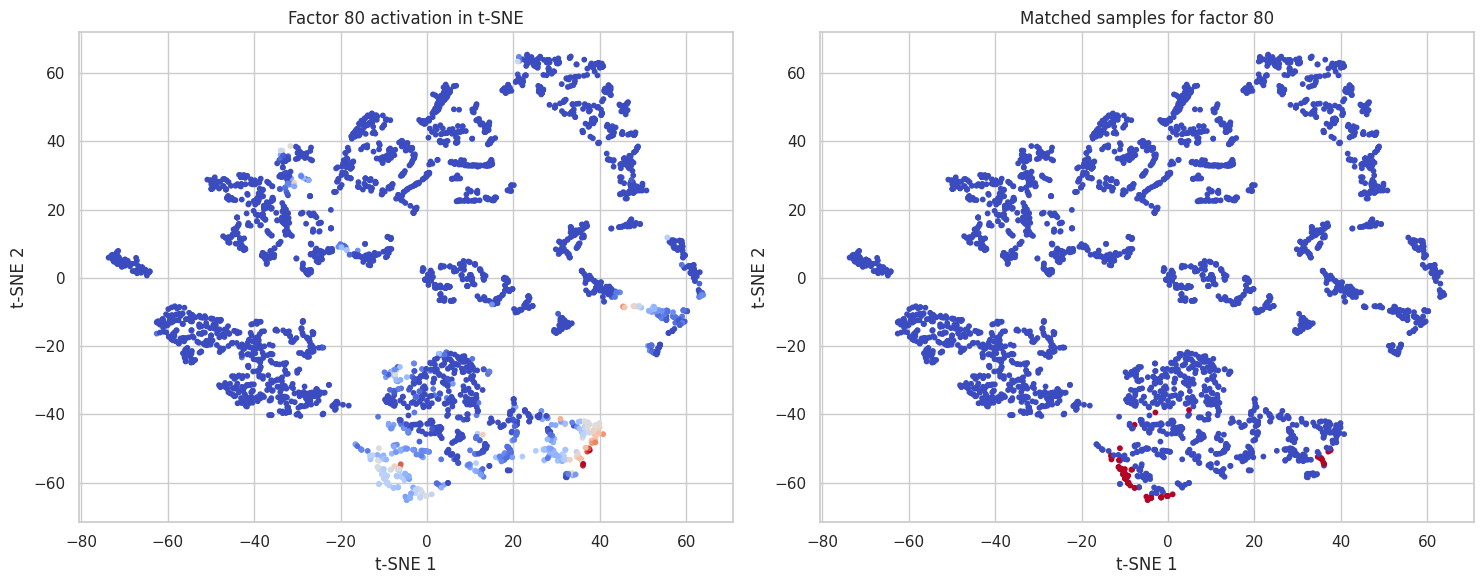

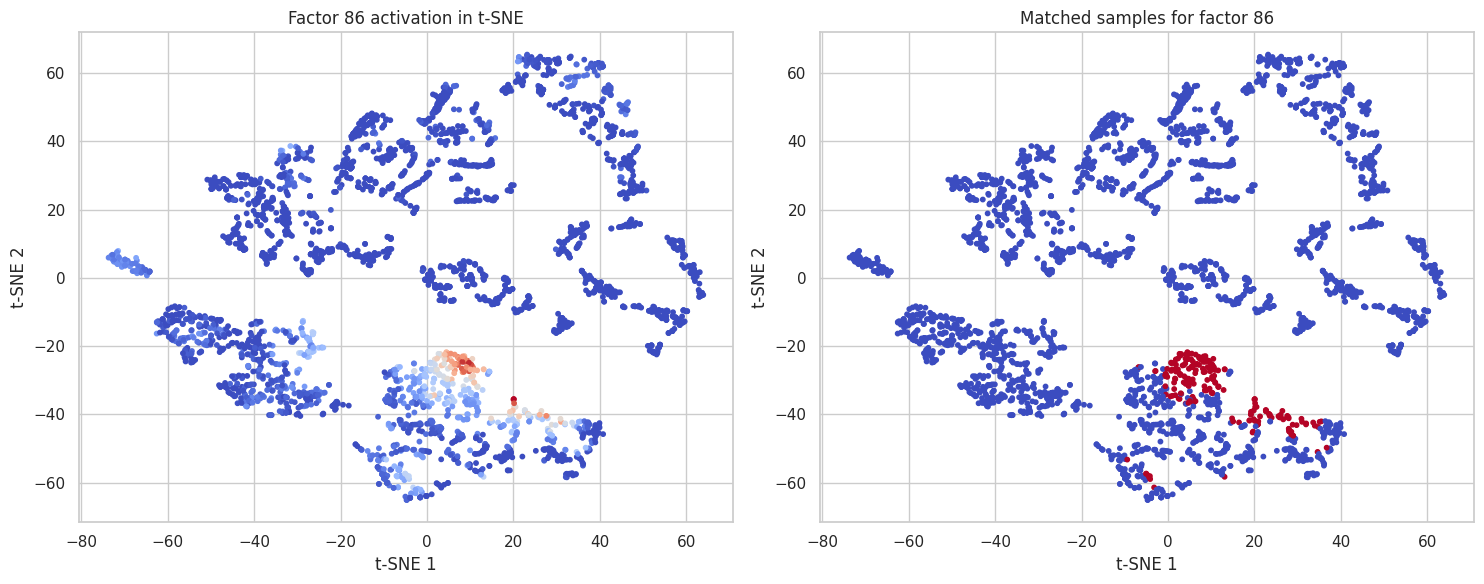

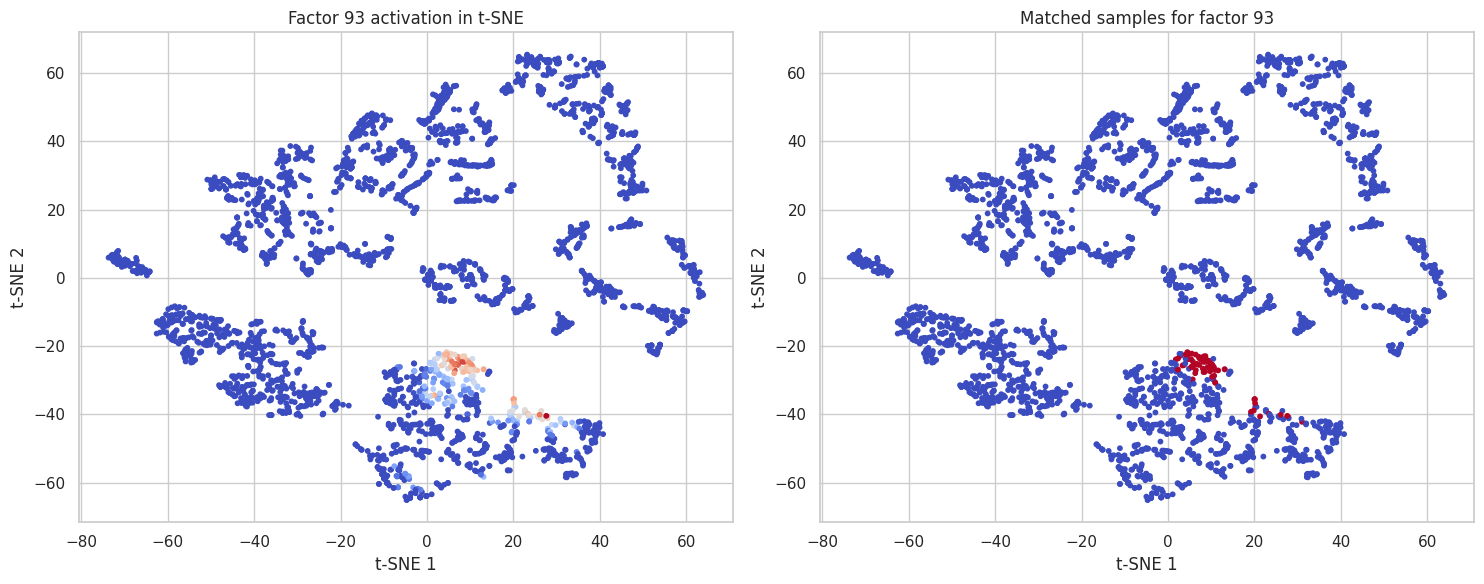

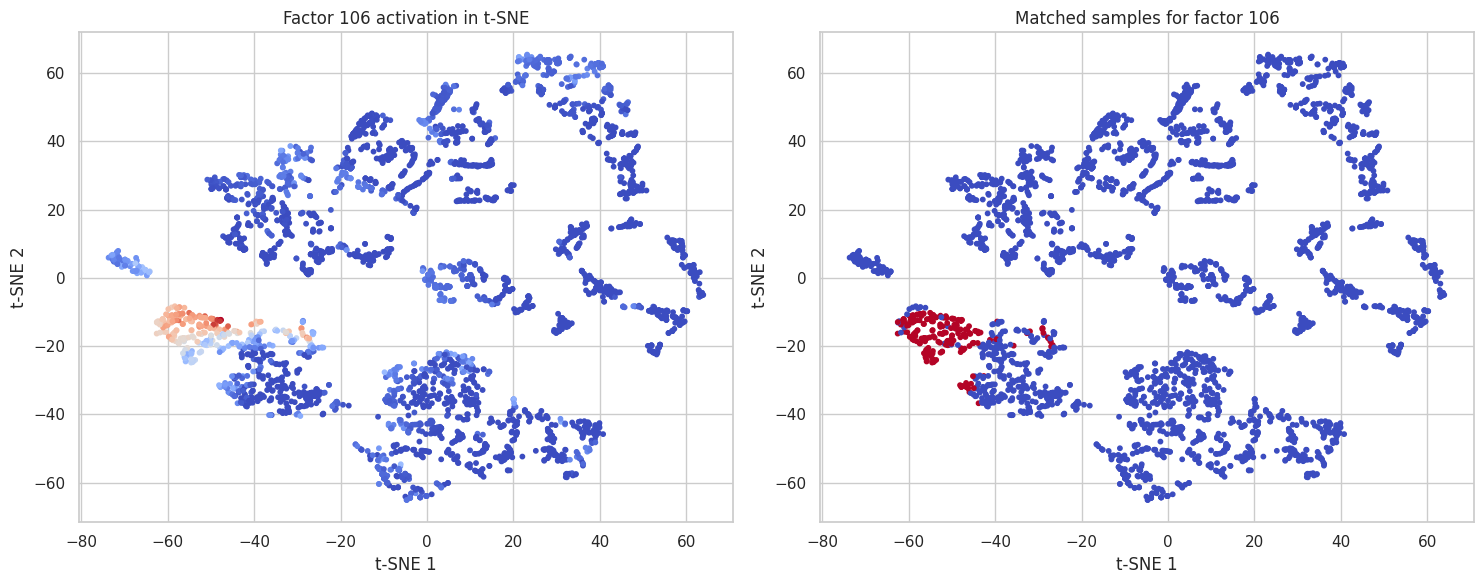

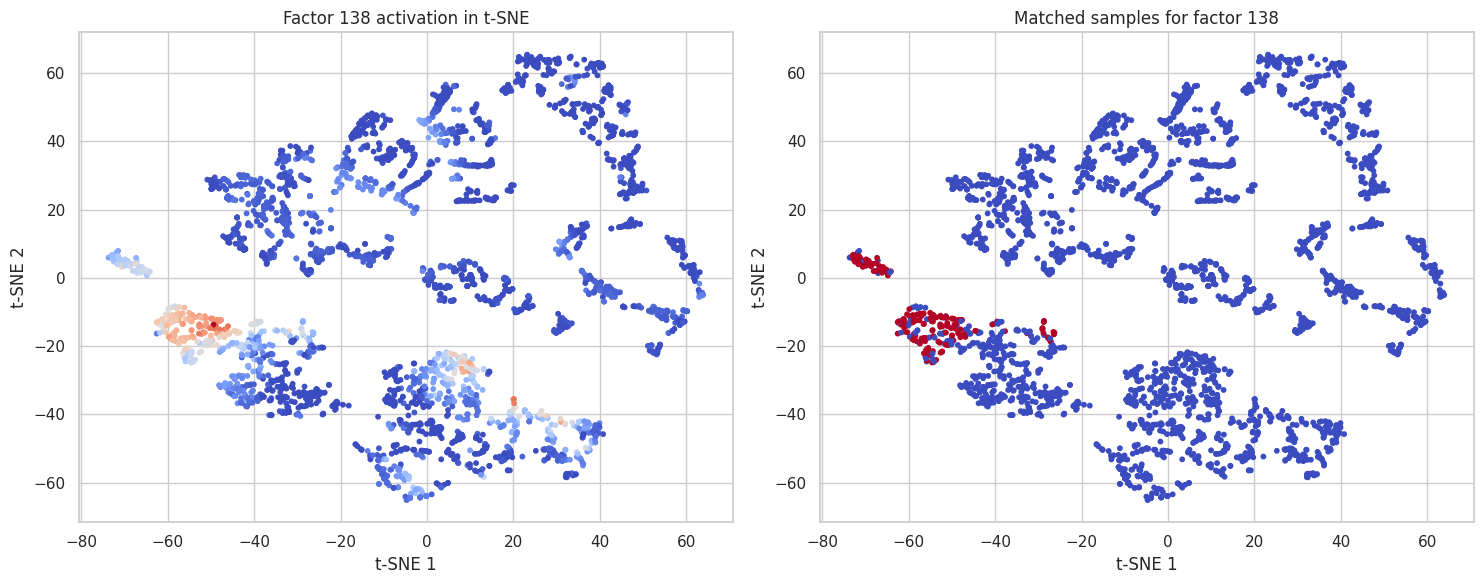

In [69]:
emb2d_held_out = tsne_2d(
    embeddings=held_out_embeddings if "held_out_embeddings" in globals() else test_emb_flat_norm[idx_test_held_out],
    random_state=42,
    perplexity=30,
)

# Plot first few matched factors
for k in matched_factors[: min(5, len(matched_factors))]:
    if k not in tree_features_validation_results:
        continue
    matched_mask = tree_features_validation_results[k]["idx_matched"]

    plot_tsne_matched_samples(
        emb2d=emb2d_held_out,
        concept_activations=held_out_concept_activations,
        matched_mask=matched_mask,
        factor_id=k,
        save_path=OUT_DIR / f"step7_tsne_factor_{k}_matched.png",
    )

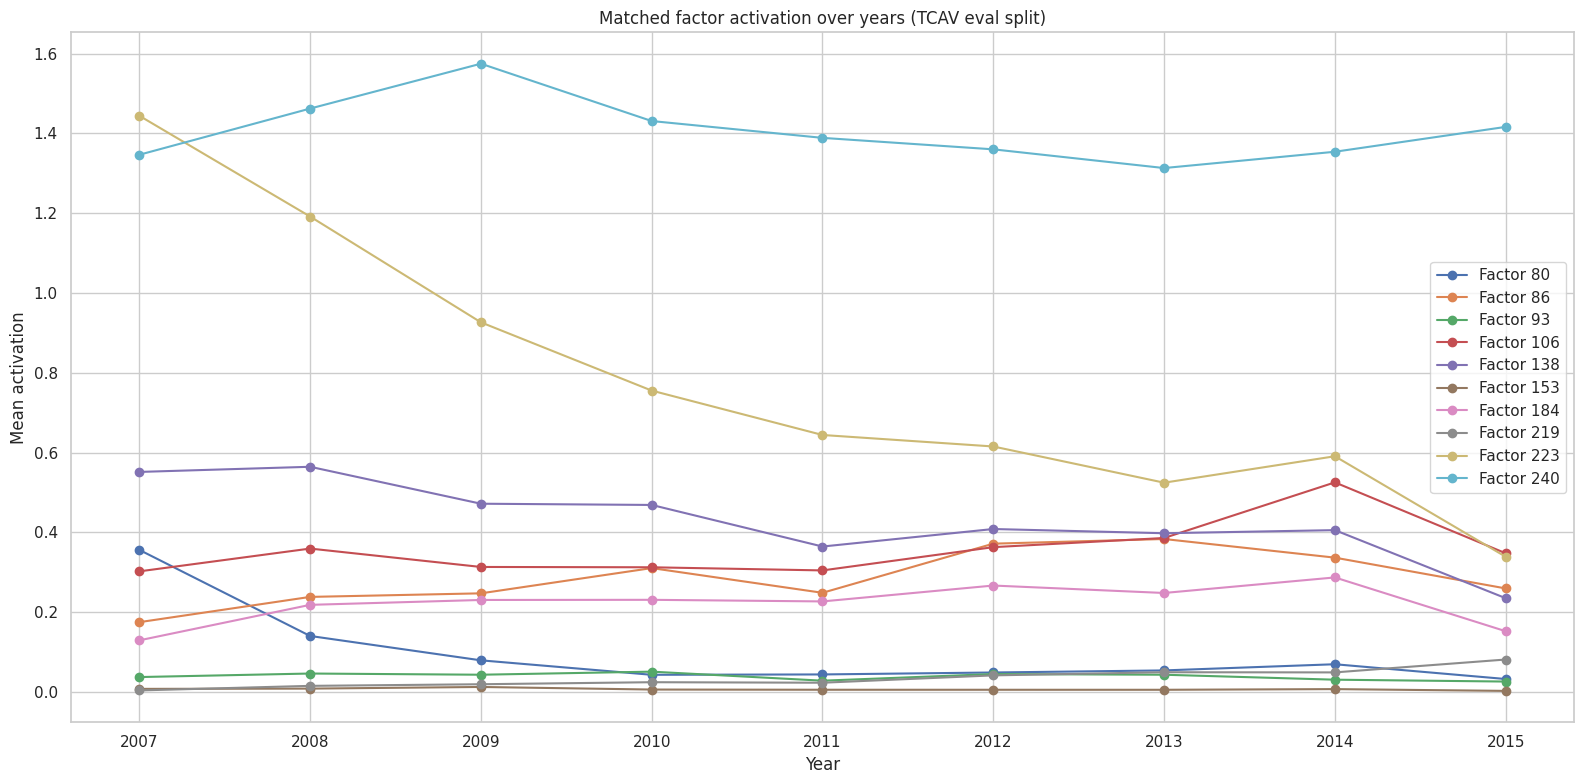

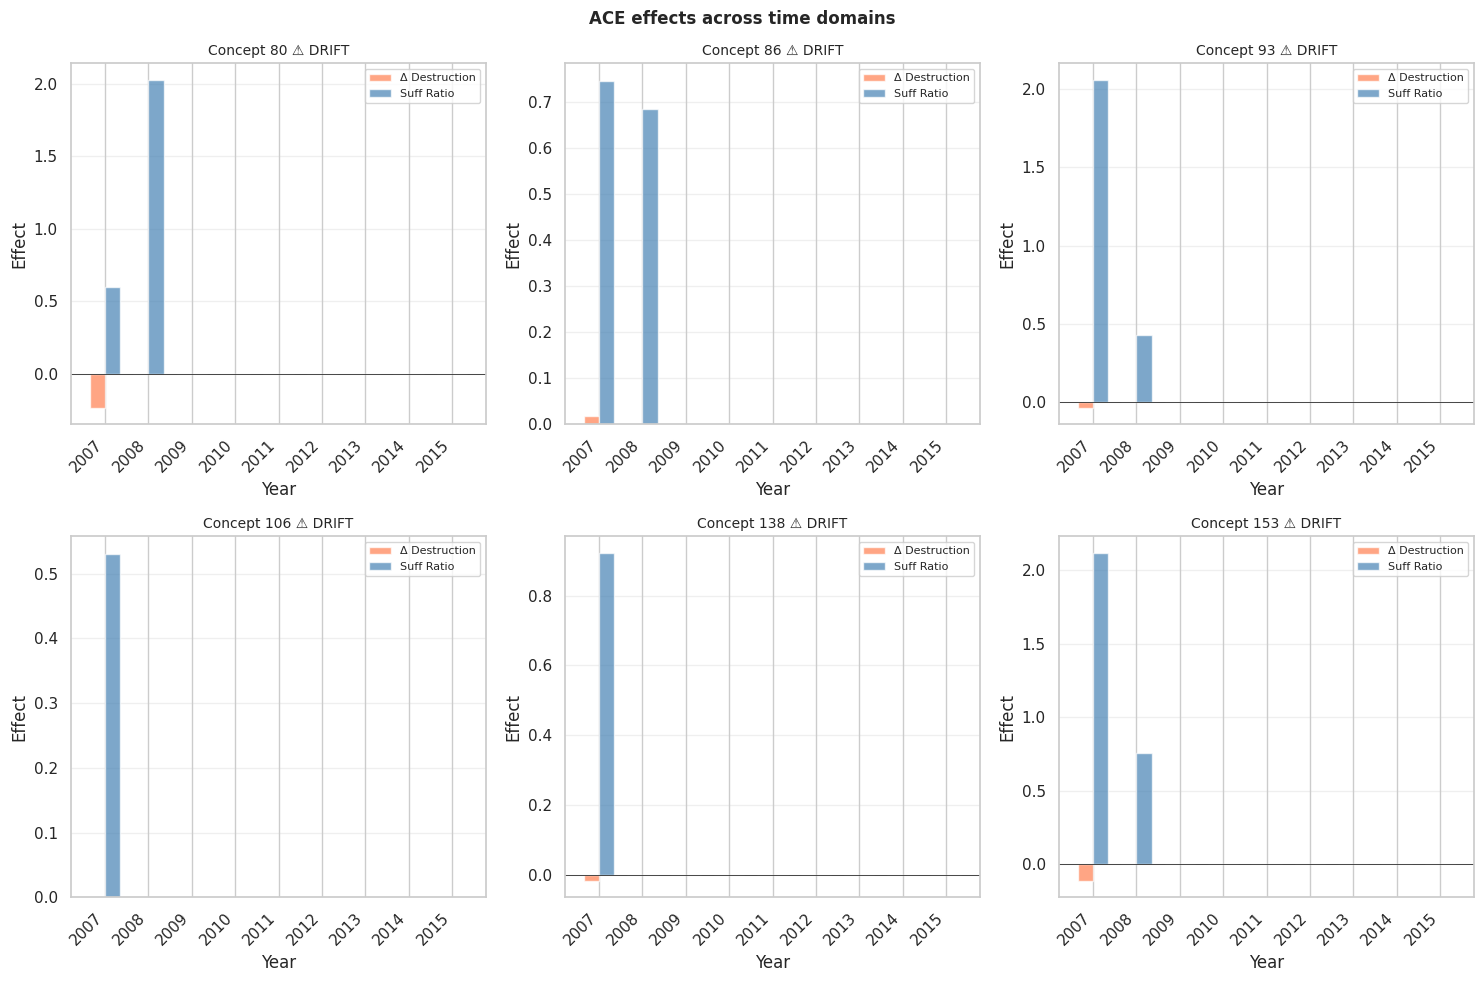

In [70]:
plot_factor_activation_over_time(
    factor_year_df=factor_year_df,
    factors=matched_factors[: min(10, len(matched_factors))],
    title="Matched factor activation over years (TCAV eval split)",
)

domain_to_year = {v: k for k, v in year_to_domain_combined.items()}

plot_drift_bars_for_concepts(
    ace_results=ace_results,
    domain_to_year=domain_to_year,
    concepts=matched_factors,
    max_plots=6,
)

In [71]:
save_csv(ace_df, OUT_DIR / "step7_ace_summary.csv", index=False)
save_csv(rule_validation_df, OUT_DIR / "step7_rule_validation_summary.csv", index=False)
save_csv(factor_year_df, OUT_DIR / "step7_factor_activation_by_year.csv", index=False)
save_csv(df_concepts_stats_per_year, OUT_DIR / "step7_feature_means_by_year.csv", index=False)

save_json(
    {
        "n_ace_results": int(len(ace_results)),
        "n_validated": int(len(validated_concepts)),
        "n_partial": int(len(partially_validated)),
        "n_failed": int(len(failed_concepts)),
        "validated_ids": [int(x["concept_id"]) for x in validated_concepts],
        "partial_ids": [int(x["concept_id"]) for x in partially_validated],
        "failed_ids": [int(x["concept_id"]) for x in failed_concepts],
        "n_rule_validations": int(len(rule_validation_df)),
    },
    OUT_DIR / "step7_ace_metadata.json",
)

print("Saved Step 7 artifacts in:", OUT_DIR)

Saved Step 7 artifacts in: results/demo_tabpfn/demo_tabpfn_step1


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from src.tabpfn_pipeline.reporting import (
    tcav_results_to_df,
    robust_tcav_results_to_df,
    decomposition_quality_report,
)

In [73]:
results_df = pd.DataFrame(results_per_year).sort_values("year").reset_index(drop=True)
print("Yearly results:")
display(results_df)

Yearly results:


,year,n_samples,n_deaths,f1_macro,f1_pos,infer_time_sec
0,2007,1894,143,0.634787,0.338028,75.547516
1,2008,2393,179,0.649099,0.369610,55.596090
2,2009,2485,219,0.664688,0.400756,55.890607
3,2010,2594,216,0.627816,0.334545,67.028161
4,2011,2520,258,0.617922,0.320144,56.013098
5,2012,2529,215,0.598367,0.277886,56.025484
6,2013,2577,191,0.606524,0.290766,66.858364
7,2014,2605,225,0.620258,0.322004,66.983194
8,2015,2303,97,0.615471,0.279863,55.888826


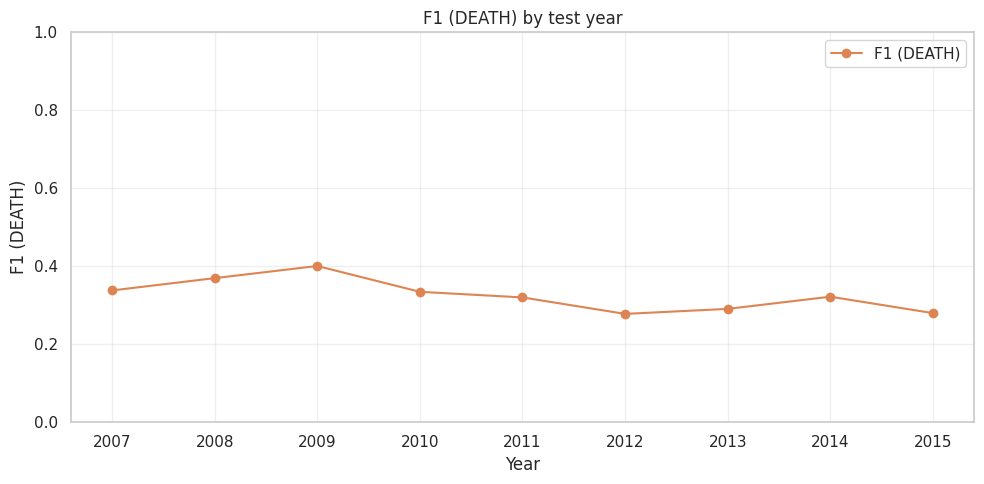

In [74]:
plt.figure(figsize=(10, 5))
plt.plot(results_df["year"], results_df["f1_pos"], marker="o", linestyle="-", color="C1", label="F1 (DEATH)")
plt.xticks(results_df["year"])
plt.xlabel("Year")
plt.ylabel("F1 (DEATH)")
plt.title("F1 (DEATH) by test year")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

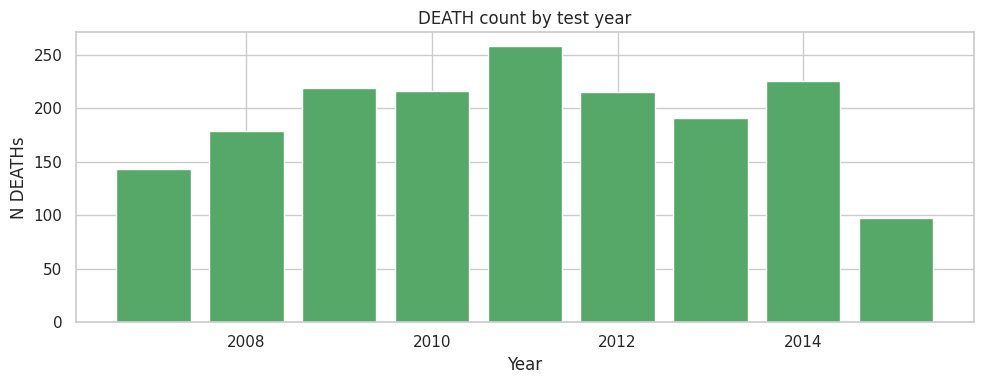

In [75]:
plt.figure(figsize=(10, 4))
plt.bar(results_df["year"], results_df["n_deaths"], color="C2")
plt.xlabel("Year")
plt.ylabel("N DEATHs")
plt.title("DEATH count by test year")
plt.tight_layout()
plt.show()

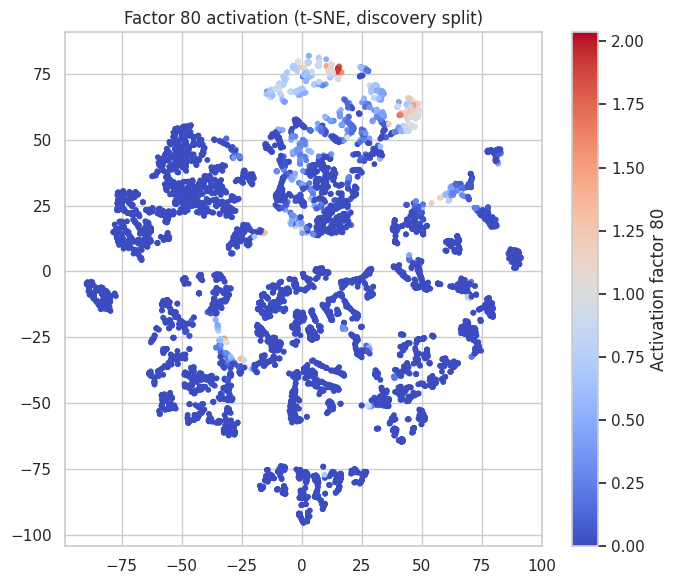

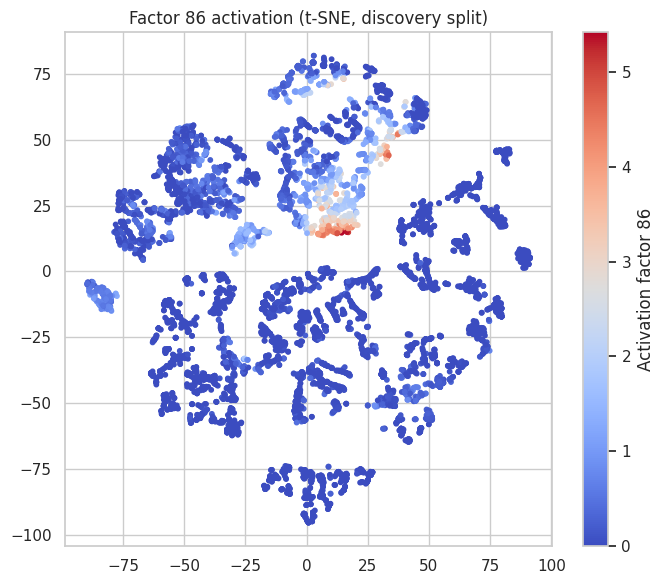

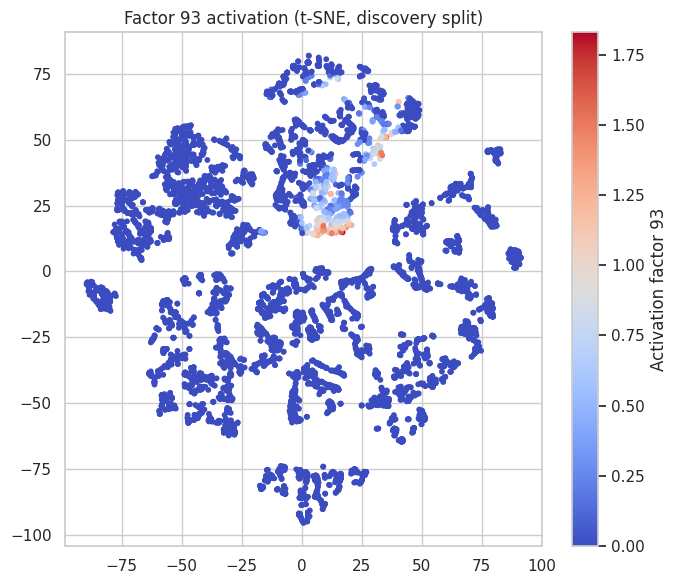

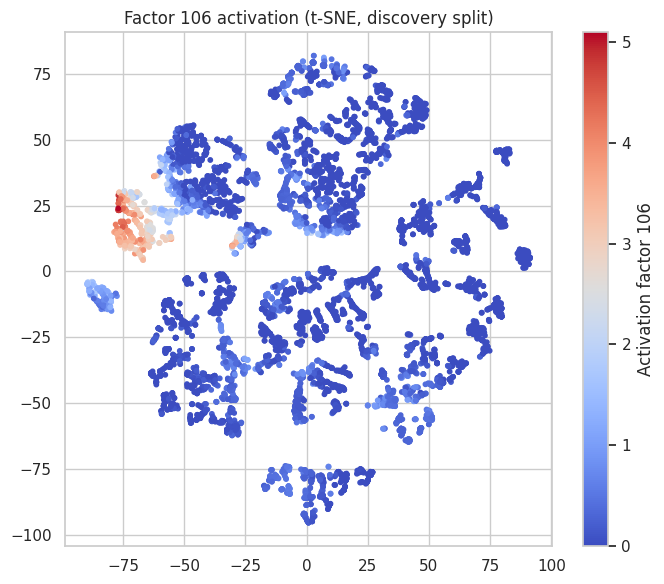

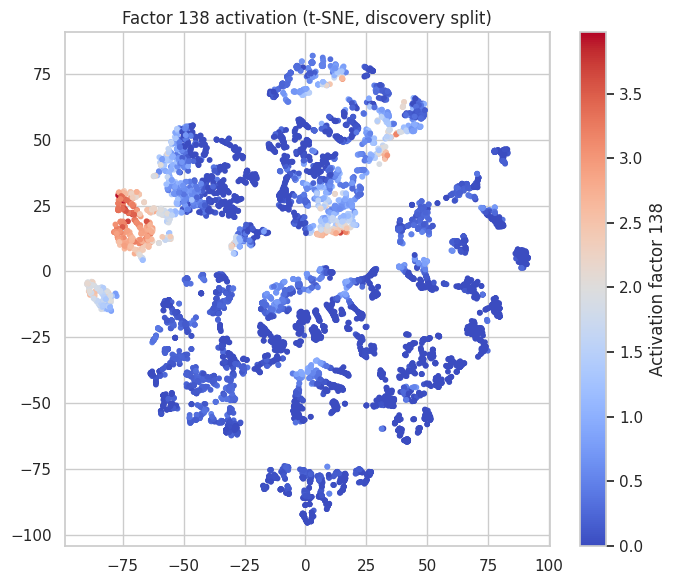

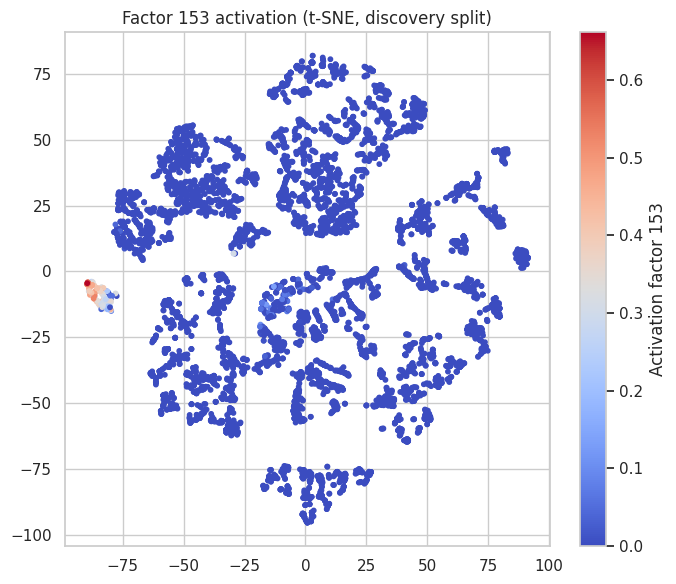

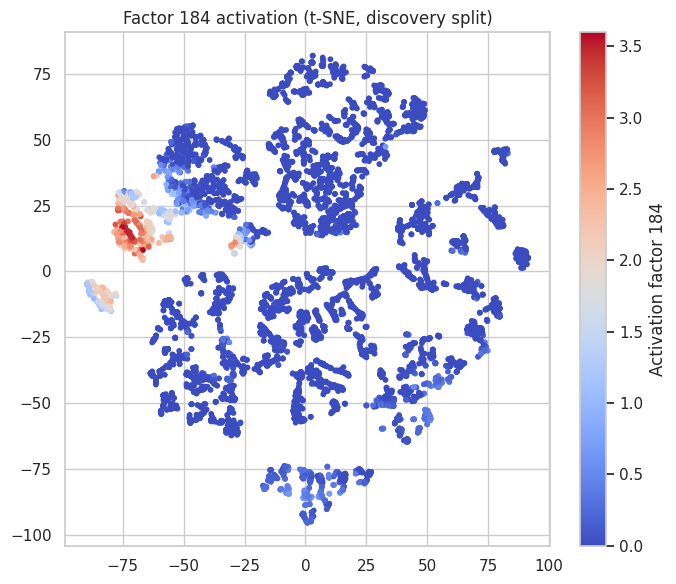

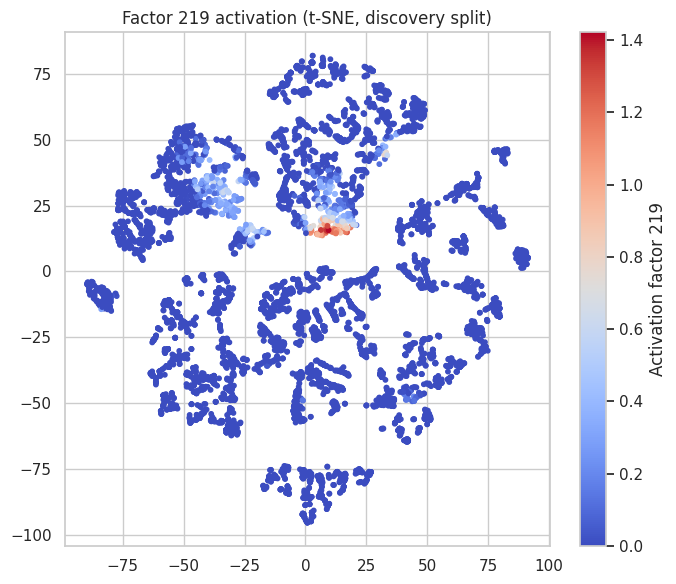

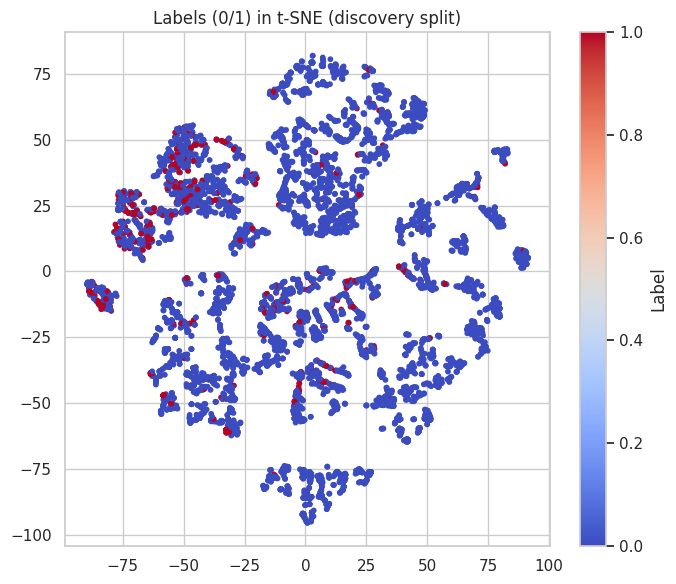

In [76]:
# use already computed emb2d_discovery if exists, else compute
if "emb2d_discovery" not in globals():
    emb2d_discovery = tsne_2d(test_emb_flat_norm[idx_test_discover], random_state=42, perplexity=30)

disc_acts = get_concept_activations(
    embeddings=test_emb_flat_norm[idx_test_discover],
    source=ANALYSIS_SOURCE,   # "sae" or "dl"
    model_sae=sae_info["model_sae"] if ANALYSIS_SOURCE == "sae" else None,
    dict_learning_info=dl_info if ANALYSIS_SOURCE == "dl" else None,
    device="cpu",
)

for k in matched_factors[: min(8, len(matched_factors))]:
    plt.figure(figsize=(7, 6))
    plt.scatter(emb2d_discovery[:, 0], emb2d_discovery[:, 1], c=disc_acts[:, k], cmap="coolwarm", s=10)
    plt.title(f"Factor {k} activation (t-SNE, discovery split)")
    plt.colorbar(label=f"Activation factor {k}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(emb2d_discovery[:, 0], emb2d_discovery[:, 1], c=y_test_discover, cmap="coolwarm", s=10)
plt.title("Labels (0/1) in t-SNE (discovery split)")
plt.colorbar(label="Label")
plt.tight_layout()
plt.show()

In [77]:
quality_report = decomposition_quality_report(
    codes_sae=sae_info["codes_train_sae"],
    decoder_atoms_sae=sae_info["decoder_atoms_sae"],
    dict_codes=dl_info["activations_discovery_train"],
    dict_atoms=dl_info["W_latent"],
    threshold=0.5,
)

print("Decomposition quality:")
for k, v in quality_report.items():
    print(f"  {k}: {v}")

Decomposition quality:
  sae_atom_max_offdiag_cos: 0.29046450859852374
  sae_atom_mean_offdiag_cos: 0.055132643231981124
  sae_atom_pairs_gt_thr: 0
  sae_code_max_offdiag_cos: 0.9972581420497195
  sae_code_mean_offdiag_cos: 0.030800981974258766
  sae_code_pairs_gt_thr: 399
  dl_atom_max_offdiag_cos: 0.9417717307821944
  dl_atom_mean_offdiag_cos: 0.6763931057186998
  dl_atom_pairs_gt_thr: 28
  dl_code_max_offdiag_cos: 0.47799922566214126
  dl_code_mean_offdiag_cos: 0.18058699674383905
  dl_code_pairs_gt_thr: 0
  sae_sparsity: 0.9055581499930815
  dl_sparsity: 0.4790542410405424


In [78]:
tcav_df_sae = tcav_results_to_df(results_sae, cav_dict_sae)
tcav_df_dl = tcav_results_to_df(results_dl, cav_dict_activ)
robust_tcav_df = robust_tcav_results_to_df(robust_tcav_results)

print("SAE TCAV:")
display(tcav_df_sae.head(30))

print("DL TCAV:")
display(tcav_df_dl.head(30))

print("Robust TCAV:")
display(robust_tcav_df.head(30))

SAE TCAV:


,cluster,tcav_prop_positive,mean_derivative,size_pure,size_neg,deriv_std,deriv_range
0,80,0.000000,-0.052329,94,94,0.002655,0.018194
1,86,0.000000,-0.032383,199,199,0.001836,0.015022
2,93,0.000000,-0.034996,61,61,0.004939,0.027903
3,106,0.049073,-0.010627,239,239,0.004843,0.026694
4,138,0.999727,0.011569,215,215,0.005607,0.031183
5,153,0.060796,-0.011981,67,67,0.007274,0.037536
6,156,0.561887,0.000508,639,639,0.004416,0.025611
7,184,0.040349,-0.010313,155,155,0.004788,0.025499
8,195,0.799891,0.007542,332,332,0.011258,0.071221
9,219,0.000000,-0.046631,61,61,0.008050,0.047196


DL TCAV:


,cluster,tcav_prop_positive,mean_derivative,size_pure,size_neg,deriv_std,deriv_range
0,0,0.00000,-0.100389,371,371,0.011822,0.075938
1,1,1.00000,0.045368,367,367,0.006298,0.039535
2,2,0.21374,-0.009349,367,367,0.012647,0.074775
3,3,0.00000,-0.023760,2767,367,0.005170,0.030815
4,4,0.00000,-0.055834,367,367,0.002851,0.019052
5,5,0.00000,-0.060986,3542,368,0.011647,0.069400
6,6,0.00000,-0.070220,367,367,0.014649,0.092840
7,7,1.00000,0.033455,367,367,0.004820,0.031150


Robust TCAV:


,concept,mean_concept_tcav,std_concept_tcav,mean_random_tcav,std_random_tcav,p_value,cohens_d,significant
0,80,0.000000,0.000000e+00,0.530189,0.469440,0.000229,-1.597223,True
1,86,0.000000,0.000000e+00,0.336587,0.448252,0.008946,-1.061915,True
2,93,0.000000,0.000000e+00,0.419320,0.458429,0.001927,-1.293567,True
3,106,0.049073,6.938894e-18,0.334842,0.428870,0.018844,-0.942333,True
4,138,0.999727,3.330669e-16,0.367575,0.444870,0.000012,2.009571,True
5,153,0.060796,0.000000e+00,0.517375,0.456616,0.000837,-1.414102,True
6,156,0.561887,2.220446e-16,0.487405,0.452646,0.543077,0.232706,False
7,184,0.040349,0.000000e+00,0.344566,0.464628,0.020803,-0.925962,True
8,195,0.799891,2.220446e-16,0.606434,0.482554,0.144797,0.566961,False
9,219,0.000000,0.000000e+00,0.419320,0.458429,0.001927,-1.293567,True


In [79]:
print("Rule validation summary:")
display(rule_validation_df.sort_values("p-value").head(30))

print("ACE summary:")
display(ace_df.sort_values("Concept").head(30))

Rule validation summary:


,SAE Factor,N Matched,N Not Matched,Matched Act Mean,Not Matched Act Mean,Cohen's d,p-value,Significant,N Conditions
5,153,72,3597,0.315900,0.001419,2.899565,0.000000e+00,True,3
9,240,622,3047,5.946014,0.497492,4.587635,0.000000e+00,True,3
10,264,72,3597,0.584991,0.003469,3.460604,0.000000e+00,True,2
11,274,473,3196,6.139523,0.351883,4.013949,8.043954e-285,True,5
8,223,400,3269,4.392307,0.306793,3.853189,1.370004e-242,True,4
2,93,72,3597,1.134388,0.022090,5.481344,2.552659e-229,True,1
6,184,155,3514,2.648361,0.105798,5.951450,6.473022e-171,True,4
1,86,218,3451,2.710895,0.155430,3.518399,1.505443e-164,True,2
3,106,215,3454,2.744736,0.185242,3.291623,3.471048e-149,True,4
7,219,72,3597,0.822372,0.022192,3.321934,2.573738e-145,True,1


ACE summary:


,Concept,Phenotype,Risk,Δ_destroy (all),Δ_destroy (high),Δ_destroy (low),Effect Ratio,Suff Ratio (all),Suff Ratio (high),Destroy Drift,Suff Drift,Drift Sensitive
0,80,"↑EVENT_C1DIALISE_HD, ↑DIAGN_N1...",PROTECTIVE,0.004244,-0.073059,0.004568,15.992128,0.148271,0.376042,5.431884e-03,0.411205,⚠️
1,86,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N1...",PROTECTIVE,-0.001792,0.001947,-0.003482,0.559256,0.193947,0.148338,3.295077e-05,0.088967,⚠️
2,93,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N1...",NEUTRAL,-0.003294,0.001421,-0.003600,0.394742,0.232474,0.161654,1.241082e-04,0.414848,⚠️
3,106,"↓EVENT_c2MED_ERITRO, ↑EVENT_C6...",RISK,-0.004717,0.000093,-0.008238,0.011272,0.191588,0.000000,3.206993e-08,0.027873,⚠️
4,138,"↑EVENT_C1DIALISE_HD, ↓DIAGN_Z9...",RISK,-0.006901,-0.000058,-0.001715,0.034087,0.252978,0.149459,3.061522e-05,0.084142,⚠️
5,153,"↓DIAGN_Z940, ↓DIAGN_N180, ↓EVE...",NEUTRAL,-0.010607,-0.010607,-0.011044,0.960403,0.272828,0.272828,1.315341e-03,0.461310,⚠️
6,184,"↓DIAGN_N180, ↑EVENT_C6INTERNA_...",RISK,-0.004078,0.000004,-0.005393,0.000803,0.213393,0.000000,1.568111e-09,0.000000,✓
7,219,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N1...",NEUTRAL,-0.006970,0.000295,-0.007923,0.037213,0.272168,0.000000,5.602111e-04,0.577792,⚠️
8,223,"↓DIAGN_Z940, ↑EVENT_c3ACESSO_C...",RISK,-0.008118,0.001866,-0.000335,1.865724,0.271216,0.000000,1.681074e-05,0.024280,⚠️
9,240,"↑EVENT_c3ACESSO_CT, ↓DIAGN_Z94...",RISK,-0.007581,0.001510,-0.016575,0.091120,0.211682,0.092055,4.872845e-06,0.024512,⚠️


In [80]:
print("Phenotype report:")
display(report_df_sae.head(50))

Phenotype report:


,Concept,Phenotype Signature,Signature R2 (CV),Signature R2 (Validation),Top Feature (Cohen d),OR (Primary),OR 95% CI,p (Primary),OR (Validation),p (Validation),Mortality High (Primary),Mortality Rest (Primary),Risk Category,Validated
0,80,"↑EVENT_C1DIALISE_HD, ↑DIAGN_N180, ↓EVENT_c2MED...",0.370718,0.400998,EVENT_C1DIALISE_HD (1.66),0.268097,(0.14-0.53),5.714193e-06,0.175271,6.698679e-08,0.024523,0.085732,PROTECTIVE,✓
1,86,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c2MED...",0.422584,0.436917,EVENT_C1DIALISE_HD (2.87),0.299879,(0.16-0.57),1.651441e-05,0.236808,1.263615e-06,0.027248,0.085429,PROTECTIVE,✓
2,93,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c3ACE...",0.256436,0.283640,EVENT_C1DIALISE_HD (0.16),1.000000,(nan-nan),1.000000e+00,1.000000,1.000000e+00,0.079607,0.000000,NEUTRAL,✓
3,106,"↓EVENT_c2MED_ERITRO, ↑EVENT_C6INTERNA_INTER, ↓...",0.053514,-0.027110,EVENT_c2MED_ERITRO (-0.65),4.413767,(3.33-5.85),1.619919e-21,5.188800,5.450656e-27,0.228883,0.063011,RISK,✓
4,138,"↑EVENT_C1DIALISE_HD, ↓DIAGN_Z940, ↓EVENT_c2MED...",0.177384,0.122291,DIAGN_Z940 (-0.88),4.323674,(3.26-5.73),7.132557e-21,4.789936,3.454312e-24,0.226158,0.063314,RISK,✓
5,153,"↓DIAGN_Z940, ↓DIAGN_N180, ↓EVENT_C1DIALISE_HD",0.013949,0.022845,EVENT_C1DIALISE_HD (-0.02),1.000000,(nan-nan),1.000000e+00,1.000000,1.000000e+00,0.079607,0.000000,NEUTRAL,✓
6,184,"↓DIAGN_N180, ↑EVENT_C6INTERNA_INTER, ↑EVENT_c3...",0.053209,0.055240,EVENT_c2MED_ERITRO (-0.67),5.290797,(4.02-6.97),1.055931e-27,5.613676,6.282912e-30,0.253406,0.060285,RISK,✓
7,219,"↑EVENT_C1DIALISE_HD, ↓DIAGN_N180, ↑EVENT_c2MED...",0.246144,0.263111,EVENT_C1DIALISE_HD (1.71),0.909789,(0.60-1.37),7.602063e-01,0.716092,1.550534e-01,0.073569,0.080279,NEUTRAL,✓
8,223,"↓DIAGN_Z940, ↑EVENT_c3ACESSO_CT, ↑EVENT_C6INTE...",0.067656,0.058918,DIAGN_Z940 (-0.53),5.503135,(4.18-7.24),3.587072e-29,6.803774,7.374334e-38,0.258856,0.059679,RISK,✓
9,240,"↑EVENT_c3ACESSO_CT, ↓DIAGN_Z940, ↑EVENT_C6INTE...",0.191420,0.192838,DIAGN_Z940 (-1.08),5.503135,(4.18-7.24),3.587072e-29,7.200640,2.129441e-40,0.258856,0.059679,RISK,✓


In [81]:
n_total = len(matched_factors)
n_robust_tcav = len(filtered_factors)
n_validated_ace = len(validated_concepts)
n_partial_ace = len(partially_validated)
n_failed_ace = len(failed_concepts)

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Matched factors (rules ∩ robust TCAV): {n_total}")
print(f"Robust TCAV significant factors:       {n_robust_tcav}")
print(f"ACE validated concepts (>=3/4):        {n_validated_ace}")
print(f"ACE partial concepts (2/4):            {n_partial_ace}")
print(f"ACE failed concepts (<2/4):            {n_failed_ace}")
print(f"Outcome-robust concepts:               {len(robust_concepts)}")

if len(results_df) > 0:
    print(f"Mean yearly F1(DEATH):                 {results_df['f1_pos'].mean():.4f}")

print("=" * 70)

FINAL SUMMARY
Matched factors (rules ∩ robust TCAV): 12
Robust TCAV significant factors:       12
ACE validated concepts (>=3/4):        1
ACE partial concepts (2/4):            0
ACE failed concepts (<2/4):            11
Outcome-robust concepts:               8
Mean yearly F1(DEATH):                 0.3260
